## Public research log safety note

This notebook preserves the experimental history, but has been sanitized for public release. Historical model-loading cells were changed to `trust_remote_code=False`, and Colab/widget metadata was removed. Some preserved outputs may therefore reflect earlier exploratory runs whose code was later corrected; the README and research notes identify superseded results explicitly.


Loading model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


TEXT:
The cat sat on the table.

TOKENS:
0 'The'
1 'Ġcat'
2 'Ġsat'
3 'Ġon'
4 'Ġthe'
5 'Ġtable'
6 '.'

Number of hidden states: 25

RESULTS:
Layer  0 | Max RMS = 0.0177 | Token = '.'
Layer  1 | Max RMS = 0.2956 | Token = 'The'
Layer  2 | Max RMS = 0.3700 | Token = 'The'
Layer  3 | Max RMS = 23.8223 | Token = 'The'
Layer  4 | Max RMS = 53.6838 | Token = 'The'
Layer  5 | Max RMS = 53.6874 | Token = 'The'
Layer  6 | Max RMS = 54.5041 | Token = 'The'
Layer  7 | Max RMS = 54.5032 | Token = 'The'
Layer  8 | Max RMS = 54.5031 | Token = 'The'
Layer  9 | Max RMS = 54.5008 | Token = 'The'
Layer 10 | Max RMS = 54.5014 | Token = 'The'
Layer 11 | Max RMS = 54.4979 | Token = 'The'
Layer 12 | Max RMS = 54.4953 | Token = 'The'
Layer 13 | Max RMS = 54.4968 | Token = 'The'
Layer 14 | Max RMS = 54.4913 | Token = 'The'
Layer 15 | Max RMS = 54.4881 | Token = 'The'
Layer 16 | Max RMS = 54.4812 | Token = 'The'
Layer 17 | Max RMS = 54.4782 | Token = 'The'
Layer 18 | Max RMS = 54.4683 | Token = 'The'
Layer 19 

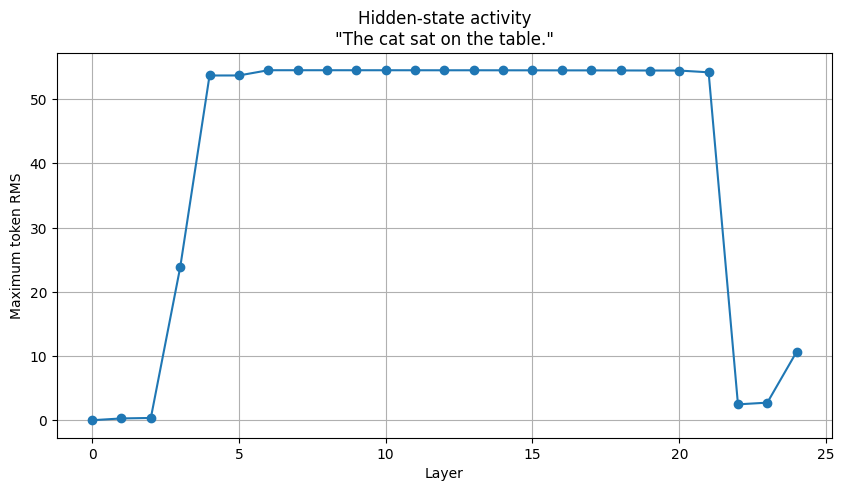

Layer: 10
Token: 'The'
Vector size: 896

Statistics:
RMS:      54.50139617919922
Mean:     2.35402512550354
Std:      54.4809455871582
Min:      -99.0
Max:      1608.0
Max |x|:  1608.0

10 largest components:
 1. dimension  62 | value =  1608.0000 | |value| =  1608.0000
 2. dimension 490 | value =   132.0000 | |value| =   132.0000
 3. dimension 570 | value =   -99.0000 | |value| =    99.0000
 4. dimension  53 | value =    97.0000 | |value| =    97.0000
 5. dimension 262 | value =    76.5000 | |value| =    76.5000
 6. dimension 591 | value =    70.5000 | |value| =    70.5000
 7. dimension 450 | value =   -62.7500 | |value| =    62.7500
 8. dimension 208 | value =    56.0000 | |value| =    56.0000
 9. dimension 844 | value =   -52.5000 | |value| =    52.5000
10. dimension 173 | value =    45.0000 | |value| =    45.0000


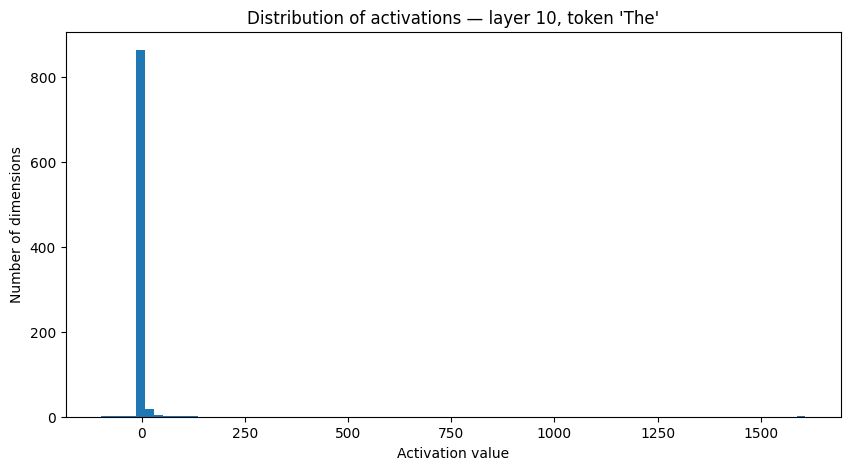

In [ ]:
# =========================
# STEP 1 — Measure hidden-state RMS
# =========================

# Install libraries
!pip install -q transformers accelerate safetensors

import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

# -------------------------
# 1. Load model
# -------------------------

model_name = "Qwen/Qwen2.5-0.5B"

print("Loading model...")

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

model.eval()

# -------------------------
# 2. Choose text
# -------------------------

text = "The cat sat on the table."

# Tokenize
inputs = tokenizer(
    text,
    return_tensors="pt"
).to(model.device)

tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)

print("\nTEXT:")
print(text)

print("\nTOKENS:")
for i, token in enumerate(tokens):
    print(i, repr(token))

# -------------------------
# 3. Run through model
# -------------------------

with torch.no_grad():
    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False
    )

hidden_states = outputs.hidden_states

print("\nNumber of hidden states:", len(hidden_states))

# -------------------------
# 4. Measure RMS
# -------------------------

max_rms_per_layer = []
max_token_per_layer = []

for layer_number, h in enumerate(hidden_states):

    # Shape:
    # [batch, tokens, hidden dimensions]

    h = h[0].float()

    # RMS for every token
    rms_per_token = torch.sqrt(
        torch.mean(h ** 2, dim=-1)
    )

    # Find largest token in this layer
    max_value, max_index = torch.max(
        rms_per_token,
        dim=0
    )

    max_rms_per_layer.append(
        max_value.item()
    )

    max_token_per_layer.append(
        tokens[max_index.item()]
    )

# -------------------------
# 5. Print results
# -------------------------

print("\nRESULTS:")

for layer, (rms, token) in enumerate(
    zip(max_rms_per_layer, max_token_per_layer)
):

    print(
        f"Layer {layer:2d} | "
        f"Max RMS = {rms:.4f} | "
        f"Token = {repr(token)}"
    )

# -------------------------
# 6. Plot
# -------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(max_rms_per_layer)),
    max_rms_per_layer,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Maximum token RMS")
plt.title(f'Hidden-state activity\n"{text}"')

plt.grid(True)

plt.show()

# =========================
# STEP 1B — Inspect the large activation
# =========================

layer = 10
token_index = 0   # "The"

# Vector of "The" at layer 10
h = hidden_states[layer][0, token_index].float().cpu()

print("Layer:", layer)
print("Token:", repr(tokens[token_index]))
print("Vector size:", len(h))

print("\nStatistics:")
print("RMS:     ", torch.sqrt(torch.mean(h**2)).item())
print("Mean:    ", torch.mean(h).item())
print("Std:     ", torch.std(h).item())
print("Min:     ", torch.min(h).item())
print("Max:     ", torch.max(h).item())
print("Max |x|: ", torch.max(torch.abs(h)).item())

# Show the 10 largest components by absolute value
values, indices = torch.topk(torch.abs(h), 10)

print("\n10 largest components:")

for rank, (abs_value, index) in enumerate(zip(values, indices), 1):
    original_value = h[index].item()

    print(
        f"{rank:2d}. dimension {index.item():3d} | "
        f"value = {original_value:10.4f} | "
        f"|value| = {abs_value.item():10.4f}"
    )

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(h.numpy(), bins=80)
plt.xlabel("Activation value")
plt.ylabel("Number of dimensions")
plt.title(f'Distribution of activations — layer {layer}, token {tokens[token_index]!r}')
plt.show()

Loading model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model loaded.

Loading 100 normal texts...


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Number of texts: 100

Example normal text:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Running baseline...

Processed 100/100

Baseline finished.

BASELINE SUMMARY

 layer  rms_median  rms_95  rms_max  max_abs_median  max_abs_95  max_abs_max
     0        0.02    0.02     0.02            0.09        0.12         0.13
     1        0.31    0.36     0.38            3.05        5.94         6.31
     2        0.38    0.43     0.46            5.50        7.06         7.53
     3       24.15   26.94    27.62          710.00      792.20       812.00
     4       53.81   56.91    57.72         1588.00     1680.00      1704.00
     5       53.82   56.91    57.72         1588.00     1680.00      1704.00
     6       54.63   57.73    58.54         1612.00     1704.00      1728.00
     7       54.63   57.73    58.54         1612.00     1704.00      1728.00
     8       54.63   57.73    58.54     

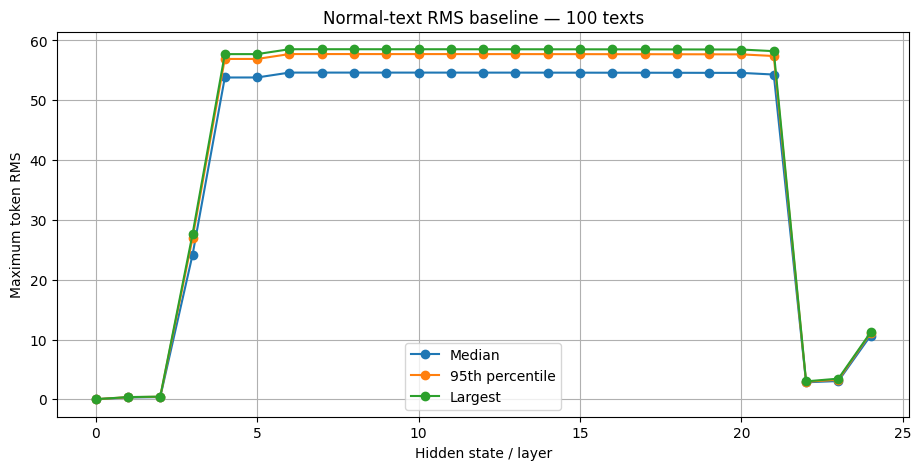

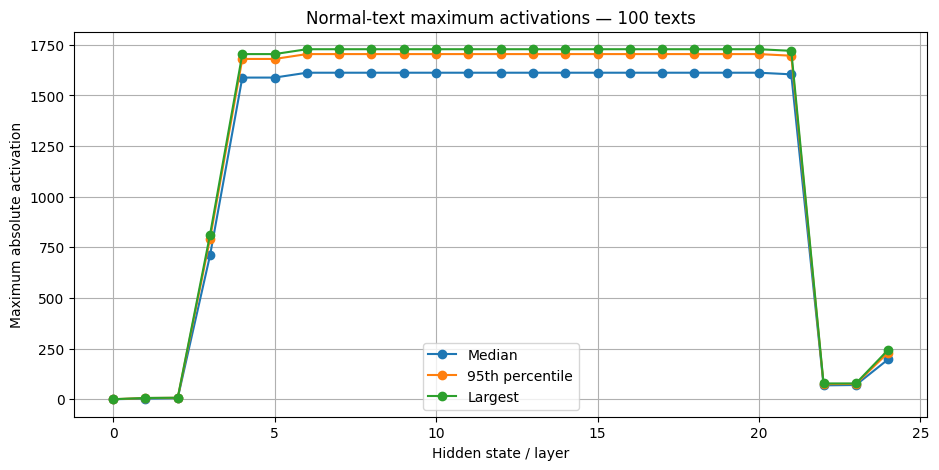


DONE


In [ ]:
# ==========================================
# STEP 2 — Build a baseline from 100 texts
# ==========================================

!pip install -q transformers accelerate safetensors datasets

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset


# ==========================================
# 1. LOAD MODEL
# ==========================================

model_name = "Qwen/Qwen2.5-0.5B"

print("Loading model...")

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

model.eval()

print("Model loaded.")


# ==========================================
# 2. LOAD 100 NORMAL TEXTS
# ==========================================

print("\nLoading 100 normal texts...")

dataset = load_dataset(
    "fancyzhx/ag_news",
    split="train[:100]"
)

texts = [example["text"] for example in dataset]

print("Number of texts:", len(texts))

print("\nExample normal text:")
print(texts[0])


# ==========================================
# 3. STORAGE FOR RESULTS
# ==========================================

all_results = []

number_of_hidden_states = None


# ==========================================
# 4. RUN ALL 100 TEXTS THROUGH THE MODEL
# ==========================================

print("\nRunning baseline...\n")

for text_index, text in enumerate(texts):

    # Convert text into tokens
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(model.device)

    tokens = tokenizer.convert_ids_to_tokens(
        inputs["input_ids"][0]
    )

    # Run through model
    with torch.no_grad():

        outputs = model(
            **inputs,
            output_hidden_states=True,
            use_cache=False
        )

    hidden_states = outputs.hidden_states

    if number_of_hidden_states is None:
        number_of_hidden_states = len(hidden_states)

    # Go through every hidden state / layer
    for layer_number, h in enumerate(hidden_states):

        # Shape:
        # [batch, tokens, hidden_dimensions]

        h = h[0].float().cpu()

        # ----------------------------------
        # METRIC 1:
        # RMS of every token
        # ----------------------------------

        rms_per_token = torch.sqrt(
            torch.mean(h ** 2, dim=-1)
        )

        max_token_rms, rms_token_index = torch.max(
            rms_per_token,
            dim=0
        )

        # ----------------------------------
        # METRIC 2:
        # Biggest individual activation
        # anywhere in this layer
        # ----------------------------------

        abs_h = torch.abs(h)

        flat_index = torch.argmax(abs_h)

        token_index = (
            flat_index // h.shape[1]
        ).item()

        dimension_index = (
            flat_index % h.shape[1]
        ).item()

        max_abs = abs_h[
            token_index,
            dimension_index
        ].item()

        actual_value = h[
            token_index,
            dimension_index
        ].item()

        # Save result
        all_results.append({

            "text_index": text_index,

            "layer": layer_number,

            "max_token_rms":
                max_token_rms.item(),

            "rms_token":
                tokens[rms_token_index.item()],

            "max_abs":
                max_abs,

            "activation_value":
                actual_value,

            "max_token":
                tokens[token_index],

            "dimension":
                dimension_index
        })

    print(
        f"Processed {text_index + 1}/100",
        end="\r"
    )


print("\n\nBaseline finished.")


# ==========================================
# 5. TURN RESULTS INTO TABLE
# ==========================================

df = pd.DataFrame(all_results)


# ==========================================
# 6. CALCULATE NORMAL BASELINE
# ==========================================

summary = df.groupby("layer").agg(

    rms_median=(
        "max_token_rms",
        "median"
    ),

    rms_95=(
        "max_token_rms",
        lambda x: np.percentile(x, 95)
    ),

    rms_max=(
        "max_token_rms",
        "max"
    ),

    max_abs_median=(
        "max_abs",
        "median"
    ),

    max_abs_95=(
        "max_abs",
        lambda x: np.percentile(x, 95)
    ),

    max_abs_max=(
        "max_abs",
        "max"
    )

).reset_index()


print("\n==========================================")
print("BASELINE SUMMARY")
print("==========================================\n")

print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# ==========================================
# 7. CHECK WHICH DIMENSIONS DOMINATE
# ==========================================

print("\n==========================================")
print("MOST COMMON MAX DIMENSIONS")
print("==========================================\n")

for layer in range(number_of_hidden_states):

    layer_df = df[
        df["layer"] == layer
    ]

    counts = (
        layer_df["dimension"]
        .value_counts()
        .head(3)
    )

    result_string = ", ".join(

        f"dim {dimension} = {count}/100 texts"

        for dimension, count in counts.items()
    )

    print(
        f"Layer {layer:2d}: {result_string}"
    )


# ==========================================
# 8. SHOW BIGGEST ACTIVATIONS FOUND
# ==========================================

print("\n==========================================")
print("10 BIGGEST ACTIVATIONS IN THE BASELINE")
print("==========================================\n")

biggest = df.sort_values(
    "max_abs",
    ascending=False
).head(10)

for _, row in biggest.iterrows():

    text_number = int(row["text_index"])
    layer = int(row["layer"])
    dimension = int(row["dimension"])

    print(
        f"Text {text_number:3d} | "
        f"Layer {layer:2d} | "
        f"Dimension {dimension:3d} | "
        f"Activation = {row['activation_value']:.2f} | "
        f"Token = {repr(row['max_token'])}"
    )


# ==========================================
# 9. PLOT RMS BASELINE
# ==========================================

plt.figure(figsize=(11, 5))

plt.plot(
    summary["layer"],
    summary["rms_median"],
    marker="o",
    label="Median"
)

plt.plot(
    summary["layer"],
    summary["rms_95"],
    marker="o",
    label="95th percentile"
)

plt.plot(
    summary["layer"],
    summary["rms_max"],
    marker="o",
    label="Largest"
)

plt.xlabel("Hidden state / layer")
plt.ylabel("Maximum token RMS")

plt.title(
    "Normal-text RMS baseline — 100 texts"
)

plt.legend()
plt.grid(True)

plt.show()


# ==========================================
# 10. PLOT MAXIMUM INDIVIDUAL ACTIVATIONS
# ==========================================

plt.figure(figsize=(11, 5))

plt.plot(
    summary["layer"],
    summary["max_abs_median"],
    marker="o",
    label="Median"
)

plt.plot(
    summary["layer"],
    summary["max_abs_95"],
    marker="o",
    label="95th percentile"
)

plt.plot(
    summary["layer"],
    summary["max_abs_max"],
    marker="o",
    label="Largest"
)

plt.xlabel("Hidden state / layer")
plt.ylabel("Maximum absolute activation")

plt.title(
    "Normal-text maximum activations — 100 texts"
)

plt.legend()
plt.grid(True)

plt.show()


print("\n==========================================")
print("DONE")
print("==========================================")

In [ ]:
# ============================================================
# STEP 3 — SEARCH FOR AN ANOMALOUS TEXT
# ============================================================

!pip install -q transformers accelerate safetensors datasets

import torch
import random
import string
import numpy as np

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset


# ============================================================
# 0. SETTINGS
# ============================================================

MODEL_NAME = "Qwen/Qwen2.5-0.5B"

N_BASELINE = 80
N_HOLDOUT = 20

POPULATION_SIZE = 6
CHILDREN_PER_PARENT = 4
SEARCH_ROUNDS = 12

MAX_LENGTH = 128

random.seed(42)
torch.manual_seed(42)


# ============================================================
# 1. LOAD MODEL
# ============================================================

print("Loading model...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto"
)

model.eval()

print("Model loaded.")


# ============================================================
# 2. LOAD 100 NORMAL TEXTS
# ============================================================

print("\nLoading normal texts...")

dataset = load_dataset(
    "fancyzhx/ag_news",
    split="train"
)

dataset = (
    dataset
    .shuffle(seed=123)
    .select(range(N_BASELINE + N_HOLDOUT))
)

texts = [x["text"] for x in dataset]

baseline_texts = texts[:N_BASELINE]
holdout_texts = texts[N_BASELINE:]

print("Baseline texts:", len(baseline_texts))
print("Holdout texts:", len(holdout_texts))


# ============================================================
# 3. FUNCTION:
#    FOR EACH LAYER × DIMENSION,
#    FIND THE BIGGEST ABSOLUTE ACTIVATION
#    ANYWHERE IN THE TEXT
# ============================================================

@torch.inference_mode()
def get_maxima(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(model.device)

    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False
    )

    layer_results = []

    for h in outputs.hidden_states:

        # [batch, tokens, dimensions]
        h = h[0].float()

        # For every dimension:
        # biggest |activation| anywhere in the text
        max_per_dimension = (
            h.abs()
            .amax(dim=0)
            .cpu()
        )

        layer_results.append(max_per_dimension)

    return torch.stack(layer_results)


# ============================================================
# 4. BUILD BASELINE
# ============================================================

print("\nBuilding detailed baseline...\n")

baseline_results = []

for i, text in enumerate(baseline_texts):

    maxima = get_maxima(text)

    baseline_results.append(maxima)

    print(
        f"Baseline {i+1}/{N_BASELINE}",
        end="\r"
    )

baseline = torch.stack(baseline_results)

# Shape:
# [texts, layers, dimensions]

print("\nBaseline complete.")
print("Baseline shape:", tuple(baseline.shape))


# ============================================================
# 5. LEARN NORMAL BEHAVIOUR
# ============================================================

baseline_median = torch.median(
    baseline,
    dim=0
).values

baseline_q95 = torch.quantile(
    baseline,
    0.95,
    dim=0
)

baseline_q99 = torch.quantile(
    baseline,
    0.99,
    dim=0
)


# ------------------------------------------------------------
# Define a robust scale.
#
# We measure:
#
#     candidate - normal_95%
#     ----------------------
#         normal scale
#
# This prevents dimension 62 from winning merely because
# its raw activation is ~1600.
# ------------------------------------------------------------

spread = baseline_q95 - baseline_median

minimum_scale = torch.maximum(
    baseline_median * 0.10,
    torch.full_like(baseline_median, 1e-3)
)

scale = torch.maximum(
    spread,
    minimum_scale
)


# ============================================================
# 6. ANOMALY SCORE
# ============================================================

def score_maxima(maxima):

    anomaly = (
        maxima - baseline_q95
    ) / scale

    # Ignore embedding layer 0
    anomaly[0] = -float("inf")

    flat_index = torch.argmax(anomaly).item()

    num_dimensions = anomaly.shape[1]

    layer = flat_index // num_dimensions
    dimension = flat_index % num_dimensions

    score = anomaly[
        layer,
        dimension
    ].item()

    return score, layer, dimension


@torch.inference_mode()
def score_text(text):

    maxima = get_maxima(text)

    score, layer, dimension = score_maxima(
        maxima
    )

    return score, layer, dimension, maxima


# ============================================================
# 7. CHECK 20 NORMAL TEXTS THE BASELINE NEVER SAW
# ============================================================

print("\nTesting untouched normal texts...\n")

holdout_scores = []

for i, text in enumerate(holdout_texts):

    score, layer, dimension, _ = score_text(text)

    holdout_scores.append(score)

    print(
        f"Holdout {i+1:2d}/{N_HOLDOUT} | "
        f"score = {score:7.2f} | "
        f"layer = {layer:2d} | "
        f"dimension = {dimension:3d}"
    )


holdout_scores = np.array(holdout_scores)

print("\n--------------------------------")
print("NORMAL HOLDOUT SCORES")
print("--------------------------------")

print(
    "Median:",
    round(float(np.median(holdout_scores)), 2)
)

print(
    "95th percentile:",
    round(float(np.percentile(holdout_scores, 95)), 2)
)

print(
    "Largest normal score:",
    round(float(np.max(holdout_scores)), 2)
)


# ============================================================
# 8. CHARACTER MUTATION
# ============================================================

CHARSET = (
    string.ascii_letters
    + string.digits
    + " "
    + ".,;:!?-_+=/\\()[]{}@#$%^&*"
)


def mutate_text(text):

    chars = list(text)

    # Usually change 1 character;
    # sometimes change 2
    number_of_changes = random.choice(
        [1, 1, 1, 2]
    )

    for _ in range(number_of_changes):

        position = random.randrange(
            len(chars)
        )

        old_character = chars[position]

        new_character = random.choice(
            CHARSET
        )

        while new_character == old_character:
            new_character = random.choice(
                CHARSET
            )

        chars[position] = new_character

    return "".join(chars)


# ============================================================
# 9. STARTING TEXT
# ============================================================

seed_text = "The cat sat on the table."

print("\n================================")
print("STARTING SEARCH")
print("================================")

seed_score, seed_layer, seed_dimension, _ = (
    score_text(seed_text)
)

print("\nStarting text:")
print(repr(seed_text))

print(
    "Starting score:",
    round(seed_score, 2)
)

print(
    "Starting layer:",
    seed_layer
)

print(
    "Starting dimension:",
    seed_dimension
)


# ============================================================
# 10. EVOLUTIONARY SEARCH
# ============================================================

population = [
    (
        seed_score,
        seed_text,
        seed_layer,
        seed_dimension
    )
]

evaluated = {
    seed_text: seed_score
}


for round_number in range(SEARCH_ROUNDS):

    new_candidates = []

    for (
        parent_score,
        parent_text,
        _,
        _
    ) in population:

        for _ in range(
            CHILDREN_PER_PARENT
        ):

            child = mutate_text(
                parent_text
            )

            if child in evaluated:
                continue

            score, layer, dimension, _ = (
                score_text(child)
            )

            evaluated[child] = score

            new_candidates.append(
                (
                    score,
                    child,
                    layer,
                    dimension
                )
            )

    # Parents + children
    population.extend(
        new_candidates
    )

    # Keep only best candidates
    population = sorted(
        population,
        key=lambda x: x[0],
        reverse=True
    )[:POPULATION_SIZE]

    best = population[0]

    print(
        f"\nRound {round_number+1:2d}/{SEARCH_ROUNDS}"
    )

    print(
        "Best score:",
        round(best[0], 2)
    )

    print(
        "Text:",
        repr(best[1])
    )

    print(
        f"Layer {best[2]}, "
        f"dimension {best[3]}"
    )


# ============================================================
# 11. FINAL RESULT
# ============================================================

best_score = population[0][0]
best_text = population[0][1]
best_layer = population[0][2]
best_dimension = population[0][3]

print("\n\n================================")
print("BEST CANDIDATE FOUND")
print("================================")

print("\nText:")
print(repr(best_text))

print(
    "\nAnomaly score:",
    round(best_score, 2)
)

print(
    "Layer:",
    best_layer
)

print(
    "Dimension:",
    best_dimension
)


# ============================================================
# 12. FIND EXACT TOKEN RESPONSIBLE
# ============================================================

inputs = tokenizer(
    best_text,
    return_tensors="pt"
).to(model.device)

tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)

with torch.inference_mode():

    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False
    )

h = (
    outputs
    .hidden_states[best_layer][0]
    .float()
    .cpu()
)

dimension_values = h[
    :,
    best_dimension
]

token_index = torch.argmax(
    dimension_values.abs()
).item()

actual_value = dimension_values[
    token_index
].item()

actual_abs = abs(actual_value)


# ============================================================
# 13. PRINT COMPARISON WITH NORMAL
# ============================================================

normal_median = baseline_median[
    best_layer,
    best_dimension
].item()

normal_q95 = baseline_q95[
    best_layer,
    best_dimension
].item()

normal_q99 = baseline_q99[
    best_layer,
    best_dimension
].item()


print("\n================================")
print("WHAT CAUSED THE SCORE?")
print("================================")

print(
    "\nToken:",
    repr(tokens[token_index])
)

print(
    "Token position:",
    token_index
)

print(
    "Activation:",
    round(actual_value, 4)
)

print(
    "\nNormal median maximum:",
    round(normal_median, 4)
)

print(
    "Normal 95% maximum:",
    round(normal_q95, 4)
)

print(
    "Normal 99% maximum:",
    round(normal_q99, 4)
)

print(
    "Candidate maximum:",
    round(actual_abs, 4)
)


# ============================================================
# 14. COMPARE CANDIDATE TO UNSEEN NORMAL TEXTS
# ============================================================

print("\n================================")
print("FINAL COMPARISON")
print("================================")

print(
    "Largest score among 20 untouched normal texts:",
    round(float(np.max(holdout_scores)), 2)
)

print(
    "Candidate score:",
    round(best_score, 2)
)

ratio = best_score / max(
    float(np.max(holdout_scores)),
    1e-6
)

print(
    "Candidate / largest normal score:",
    round(ratio, 2)
)


print("\n================================")
print("SEARCH COMPLETE")
print("================================")

Loading model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model loaded.

Loading normal texts...
Baseline texts: 80
Holdout texts: 20

Building detailed baseline...

Baseline 80/80
Baseline complete.
Baseline shape: (80, 25, 896)

Testing untouched normal texts...

Holdout  1/20 | score =    4.85 | layer = 19 | dimension = 543
Holdout  2/20 | score =    2.15 | layer = 24 | dimension = 194
Holdout  3/20 | score =    2.57 | layer = 11 | dimension = 845
Holdout  4/20 | score =    3.41 | layer = 13 | dimension = 759
Holdout  5/20 | score =    2.47 | layer = 22 | dimension = 760
Holdout  6/20 | score =    3.76 | layer = 20 | dimension = 848
Holdout  7/20 | score =    3.56 | layer = 20 | dimension = 848
Holdout  8/20 | score =    3.68 | layer = 16 | dimension = 512
Holdout  9/20 | score =    1.52 | layer =  1 | dimension = 332
Holdout 10/20 | score =    2.34 | layer = 19 | dimension =  47
Holdout 11/20 | score =    3.07 | layer = 22 | dimension = 582
Holdout 12/20 | score =    2.77 | layer = 22 | dimension = 193
Holdout 13/20 | score =    4.52 | la

In [ ]:
# ============================================================
# STEP 4 — FULL SELF-CONTAINED CONTROL TEST
# ============================================================

!pip install -q transformers accelerate safetensors datasets

import torch
import random
import string
import numpy as np

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset


# ============================================================
# SETTINGS
# ============================================================

MODEL_NAME = "Qwen/Qwen2.5-0.5B"

N_BASELINE = 80
N_CONTROLS = 500
MAX_LENGTH = 128

SEED = "The cat sat on the table."
CANDIDATE = "The cat sat on ]hk2taDle."

random.seed(42)
torch.manual_seed(42)


# ============================================================
# 1. LOAD MODEL
# ============================================================

print("Loading model...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto"
)

model.eval()

print("Model loaded.")


# ============================================================
# 2. FUNCTION: GET MAX ACTIVATION PER LAYER × DIMENSION
# ============================================================

@torch.inference_mode()
def get_maxima(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(model.device)

    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False
    )

    results = []

    for h in outputs.hidden_states:

        # [tokens, dimensions]
        h = h[0].float()

        # max absolute activation over all tokens
        maxima = h.abs().amax(dim=0).cpu()

        results.append(maxima)

    return torch.stack(results)


# ============================================================
# 3. LOAD BASELINE TEXTS
# ============================================================

print("\nLoading baseline texts...")

dataset = load_dataset(
    "fancyzhx/ag_news",
    split="train"
)

dataset = (
    dataset
    .shuffle(seed=123)
)

baseline_texts = [
    dataset[i]["text"]
    for i in range(N_BASELINE)
]


# ============================================================
# 4. BUILD BASELINE
# ============================================================

print("\nBuilding baseline...")

baseline_results = []

for i, text in enumerate(baseline_texts):

    baseline_results.append(
        get_maxima(text)
    )

    print(
        f"Baseline {i+1}/{N_BASELINE}",
        end="\r"
    )

baseline = torch.stack(
    baseline_results
)

print("\nBaseline complete.")
print("Shape:", tuple(baseline.shape))


# ============================================================
# 5. LEARN NORMAL VALUES
# ============================================================

baseline_median = torch.median(
    baseline,
    dim=0
).values

baseline_q95 = torch.quantile(
    baseline,
    0.95,
    dim=0
)

spread = (
    baseline_q95
    - baseline_median
)

minimum_scale = torch.maximum(
    baseline_median * 0.10,
    torch.full_like(
        baseline_median,
        1e-3
    )
)

scale = torch.maximum(
    spread,
    minimum_scale
)


# ============================================================
# 6. SCORE FUNCTION
# ============================================================

def score_maxima(maxima):

    anomaly = (
        maxima - baseline_q95
    ) / scale

    # ignore embedding state
    anomaly[0] = -float("inf")

    flat_index = torch.argmax(
        anomaly
    ).item()

    dimensions = anomaly.shape[1]

    layer = (
        flat_index // dimensions
    )

    dimension = (
        flat_index % dimensions
    )

    score = anomaly[
        layer,
        dimension
    ].item()

    return score, layer, dimension


@torch.inference_mode()
def score_text(text):

    maxima = get_maxima(text)

    score, layer, dimension = (
        score_maxima(maxima)
    )

    return (
        score,
        layer,
        dimension,
        maxima
    )


# ============================================================
# 7. SCORE OUR CANDIDATE
# ============================================================

print("\nScoring candidate...")

candidate_score, candidate_layer, candidate_dim, _ = (
    score_text(CANDIDATE)
)

candidate_tokens = tokenizer(
    CANDIDATE,
    add_special_tokens=False
)["input_ids"]

candidate_token_count = len(
    candidate_tokens
)

print("\nCandidate:")
print(repr(CANDIDATE))

print(
    "Candidate score:",
    round(candidate_score, 3)
)

print(
    "Layer:",
    candidate_layer
)

print(
    "Dimension:",
    candidate_dim
)

print(
    "Token count:",
    candidate_token_count
)


# ============================================================
# 8. COUNT CHARACTER DIFFERENCES
# ============================================================

differences = sum(
    a != b
    for a, b in zip(
        SEED,
        CANDIDATE
    )
)

print(
    "Changed characters:",
    differences
)


# ============================================================
# 9. 500 NEW NATURAL CONTROLS
# ============================================================

print("\nPreparing 500 natural controls...")

natural_controls = []

# Start after texts used in baseline
start_index = 1000

for i in range(
    start_index,
    start_index + N_CONTROLS
):

    text = dataset[i]["text"]

    ids = tokenizer(
        text,
        add_special_tokens=False
    )["input_ids"]

    # Match candidate's token length
    ids = ids[
        :candidate_token_count
    ]

    if len(ids) == 0:
        continue

    text = tokenizer.decode(
        ids,
        skip_special_tokens=True
    )

    natural_controls.append(text)

natural_controls = (
    natural_controls[:N_CONTROLS]
)


# ============================================================
# 10. SCORE NATURAL CONTROLS
# ============================================================

print("\nScoring natural controls...")

natural_scores = []

for i, text in enumerate(
    natural_controls
):

    score, _, _, _ = score_text(
        text
    )

    natural_scores.append(score)

    if (i + 1) % 25 == 0:

        print(
            f"Natural {i+1}/{N_CONTROLS}",
            end="\r"
        )

print("\nNatural controls finished.")


# ============================================================
# 11. MAKE RANDOM MUTATIONS
# ============================================================

CHARSET = (
    string.ascii_letters
    + string.digits
    + " "
    + ".,;:!?-_+=/\\()[]{}@#$%^&*"
)


def random_equal_mutation(
    text,
    n_changes
):

    chars = list(text)

    positions = random.sample(
        range(len(chars)),
        n_changes
    )

    for position in positions:

        original = chars[position]

        replacement = random.choice(
            CHARSET
        )

        while replacement == original:

            replacement = random.choice(
                CHARSET
            )

        chars[position] = replacement

    return "".join(chars)


random_controls = []

seen = set()

while len(random_controls) < N_CONTROLS:

    text = random_equal_mutation(
        SEED,
        differences
    )

    if text not in seen:

        seen.add(text)

        random_controls.append(text)


# ============================================================
# 12. SCORE RANDOM MUTATIONS
# ============================================================

print("\nScoring random mutations...")

random_scores = []

best_random_score = -float("inf")
best_random_text = None

for i, text in enumerate(
    random_controls
):

    score, _, _, _ = score_text(
        text
    )

    random_scores.append(score)

    if score > best_random_score:

        best_random_score = score
        best_random_text = text

    if (i + 1) % 25 == 0:

        print(
            f"Random {i+1}/{N_CONTROLS}",
            end="\r"
        )

print("\nRandom controls finished.")


# ============================================================
# 13. RESULTS
# ============================================================

natural_scores = np.array(
    natural_scores
)

random_scores = np.array(
    random_scores
)


def show_stats(name, scores):

    print("\n" + name)

    print(
        "Median:",
        round(
            float(np.median(scores)),
            3
        )
    )

    print(
        "95th percentile:",
        round(
            float(
                np.percentile(
                    scores,
                    95
                )
            ),
            3
        )
    )

    print(
        "99th percentile:",
        round(
            float(
                np.percentile(
                    scores,
                    99
                )
            ),
            3
        )
    )

    print(
        "Maximum:",
        round(
            float(np.max(scores)),
            3
        )
    )


print("\n\n====================================")
print("RESULTS")
print("====================================")

print(
    "\nCANDIDATE:",
    round(candidate_score, 3)
)

show_stats(
    "500 NATURAL TEXTS",
    natural_scores
)

show_stats(
    "500 RANDOM MUTATIONS",
    random_scores
)


# ============================================================
# 14. FINAL RANKING
# ============================================================

combined = np.concatenate(
    [
        natural_scores,
        random_scores
    ]
)

percentile = (
    np.mean(
        combined < candidate_score
    )
    * 100
)

beating_candidate = np.sum(
    combined >= candidate_score
)


print("\n====================================")
print("FINAL TEST")
print("====================================")

print(
    "Candidate score:",
    round(candidate_score, 3)
)

print(
    "Candidate percentile:",
    round(float(percentile), 2),
    "%"
)

print(
    "Controls >= candidate:",
    int(beating_candidate),
    "/",
    len(combined)
)


print("\nBest random mutation:")
print(
    repr(best_random_text)
)

print(
    "Best random score:",
    round(
        best_random_score,
        3
    )
)

print("\n====================================")
print("DONE")
print("====================================")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 11.9 MB/s eta 0:00:00
Loading model...


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]


Building baseline...
Baseline 80/80
Baseline complete.
Shape: (80, 25, 896)

Scoring candidate...

Candidate:
'The cat sat on ]hk2taDle.'
Candidate score: 8.16
Layer: 12
Dimension: 78
Token count: 11
Changed characters: 4

Preparing 500 natural controls...

Scoring natural controls...
Natural 500/500
Natural controls finished.

Scoring random mutations...
Random 500/500
Random controls finished.


RESULTS

CANDIDATE: 8.16

500 NATURAL TEXTS
Median: 2.14
95th percentile: 3.64
99th percentile: 4.507
Maximum: 5.826

500 RANDOM MUTATIONS
Median: 2.814
95th percentile: 3.199
99th percentile: 6.457
Maximum: 7.643

FINAL TEST
Candidate score: 8.16
Candidate percentile: 100.0 %
Controls >= candidate: 0 / 1000

Best random mutation:
'The cat ?at9onBthe tzble.'
Best random score: 7.643

DONE


In [ ]:
# ============================================================
# STEP 5 — TRANSFER TEST ON A COMPLETELY DIFFERENT MODEL
# Model B: TinyLlama-1.1B-Chat-v1.0
# ============================================================

!pip install -q transformers accelerate safetensors datasets

import torch
import random
import string
import numpy as np

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset


# ============================================================
# SETTINGS
# ============================================================

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

SEED = "The cat sat on the table."

# LOCKED candidate discovered ONLY on Qwen.
# DO NOT CHANGE THIS STRING.
CANDIDATE = "The cat sat on ]hk2taDle."

N_BASELINE = 80
N_NATURAL_CONTROLS = 500
N_RANDOM_CONTROLS = 500

MAX_LENGTH = 128

random.seed(42)
torch.manual_seed(42)


# ============================================================
# 1. LOAD MODEL B
# ============================================================

print("====================================")
print("TRANSFER TEST — MODEL B")
print("====================================")

print("\nLoading TinyLlama...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto"
)

model.eval()

print("Model loaded.")


# ============================================================
# 2. SHOW HOW MODEL B TOKENIZES OUR LOCKED CANDIDATE
# ============================================================

candidate_ids = tokenizer(
    CANDIDATE,
    add_special_tokens=False
)["input_ids"]

candidate_tokens = tokenizer.convert_ids_to_tokens(
    candidate_ids
)

candidate_token_count = len(candidate_ids)

print("\n====================================")
print("LOCKED CANDIDATE")
print("====================================")

print("\nText:")
print(repr(CANDIDATE))

print("\nTinyLlama token count:")
print(candidate_token_count)

print("\nTinyLlama tokens:")

for i, token in enumerate(candidate_tokens):
    print(i, repr(token))


# ============================================================
# 3. GET MAX ABSOLUTE ACTIVATION
#    FOR EACH LAYER × DIMENSION
# ============================================================

@torch.inference_mode()
def get_maxima(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(model.device)

    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False
    )

    results = []

    for h in outputs.hidden_states:

        # [batch, tokens, dimensions]
        h = h[0].float()

        # For every dimension:
        # maximum |activation| anywhere in the sequence
        maxima = (
            h.abs()
             .amax(dim=0)
             .cpu()
        )

        results.append(maxima)

    return torch.stack(results)


# ============================================================
# 4. LOAD DATASET
# ============================================================

print("\nLoading normal-text dataset...")

dataset = load_dataset(
    "fancyzhx/ag_news",
    split="train"
)

dataset = dataset.shuffle(seed=98765)


# ============================================================
# 5. BUILD TINYLLAMA'S OWN BASELINE
# ============================================================

print("\nBuilding TinyLlama baseline...")

baseline_results = []

for i in range(N_BASELINE):

    text = dataset[i]["text"]

    baseline_results.append(
        get_maxima(text)
    )

    print(
        f"Baseline {i+1}/{N_BASELINE}",
        end="\r"
    )

baseline = torch.stack(
    baseline_results
)

print("\nBaseline complete.")

print(
    "Baseline shape:",
    tuple(baseline.shape)
)


# ============================================================
# 6. LEARN WHAT IS NORMAL FOR EVERY
#    LAYER × DIMENSION IN TINYLLAMA
# ============================================================

baseline_median = torch.median(
    baseline,
    dim=0
).values

baseline_q95 = torch.quantile(
    baseline,
    0.95,
    dim=0
)

baseline_q99 = torch.quantile(
    baseline,
    0.99,
    dim=0
)

spread = (
    baseline_q95
    - baseline_median
)

minimum_scale = torch.maximum(
    baseline_median * 0.10,
    torch.full_like(
        baseline_median,
        1e-3
    )
)

scale = torch.maximum(
    spread,
    minimum_scale
)


# ============================================================
# 7. DEFINE ANOMALY SCORE
# ============================================================

def score_maxima(maxima):

    anomaly = (
        maxima - baseline_q95
    ) / scale

    # Ignore embedding state
    anomaly[0] = -float("inf")

    flat_index = torch.argmax(
        anomaly
    ).item()

    n_dimensions = anomaly.shape[1]

    layer = (
        flat_index // n_dimensions
    )

    dimension = (
        flat_index % n_dimensions
    )

    score = anomaly[
        layer,
        dimension
    ].item()

    return (
        score,
        layer,
        dimension
    )


@torch.inference_mode()
def score_text(text):

    maxima = get_maxima(text)

    score, layer, dimension = (
        score_maxima(maxima)
    )

    return (
        score,
        layer,
        dimension,
        maxima
    )


# ============================================================
# 8. SCORE THE LOCKED CANDIDATE
# ============================================================

print("\nScoring LOCKED candidate on TinyLlama...")

(
    candidate_score,
    candidate_layer,
    candidate_dimension,
    candidate_maxima
) = score_text(CANDIDATE)

print("\nCandidate score:")
print(round(candidate_score, 4))

print("Winning layer:")
print(candidate_layer)

print("Winning dimension:")
print(candidate_dimension)


# ============================================================
# 9. FIND THE EXACT TOKEN RESPONSIBLE
# ============================================================

inputs = tokenizer(
    CANDIDATE,
    return_tensors="pt"
).to(model.device)

with torch.inference_mode():

    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False
    )

candidate_all_tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)

h = (
    outputs
    .hidden_states[candidate_layer][0]
    .float()
    .cpu()
)

dimension_values = h[
    :,
    candidate_dimension
]

winning_token_index = torch.argmax(
    dimension_values.abs()
).item()

winning_value = dimension_values[
    winning_token_index
].item()


print("\nWinning token:")
print(
    repr(
        candidate_all_tokens[
            winning_token_index
        ]
    )
)

print(
    "Activation:",
    round(winning_value, 4)
)

print(
    "Normal median:",
    round(
        baseline_median[
            candidate_layer,
            candidate_dimension
        ].item(),
        4
    )
)

print(
    "Normal 95%:",
    round(
        baseline_q95[
            candidate_layer,
            candidate_dimension
        ].item(),
        4
    )
)

print(
    "Normal 99%:",
    round(
        baseline_q99[
            candidate_layer,
            candidate_dimension
        ].item(),
        4
    )
)


# ============================================================
# 10. NATURAL CONTROLS
#
# We match sequence length to candidate token count.
# ============================================================

print("\n====================================")
print("BUILDING NATURAL CONTROLS")
print("====================================")

natural_controls = []

dataset_index = 1000

while (
    len(natural_controls)
    < N_NATURAL_CONTROLS
):

    text = dataset[
        dataset_index
    ]["text"]

    dataset_index += 1

    ids = tokenizer(
        text,
        add_special_tokens=False
    )["input_ids"]

    # Need at least candidate length
    if len(ids) < candidate_token_count:
        continue

    # Truncate exactly to candidate token count
    ids = ids[
        :candidate_token_count
    ]

    control_text = tokenizer.decode(
        ids,
        skip_special_tokens=True
    )

    # Verify re-tokenization gives same length
    re_ids = tokenizer(
        control_text,
        add_special_tokens=False
    )["input_ids"]

    if len(re_ids) != candidate_token_count:
        continue

    natural_controls.append(
        control_text
    )

print(
    "Natural controls prepared:",
    len(natural_controls)
)


# ============================================================
# 11. SCORE NATURAL CONTROLS
# ============================================================

print("\nScoring natural controls...")

natural_scores = []

for i, text in enumerate(
    natural_controls
):

    score, _, _, _ = score_text(
        text
    )

    natural_scores.append(
        score
    )

    if (i + 1) % 25 == 0:

        print(
            f"Natural {i+1}/{N_NATURAL_CONTROLS}",
            end="\r"
        )

print("\nNatural controls complete.")


# ============================================================
# 12. HOW MANY CHARACTERS DIFFER?
# ============================================================

differences = sum(
    a != b
    for a, b in zip(
        SEED,
        CANDIDATE
    )
)

print(
    "\nCandidate differs from seed at",
    differences,
    "character positions."
)


# ============================================================
# 13. RANDOM MUTATIONS
#
# Same:
#   - starting sentence
#   - number of character changes
#   - TinyLlama token count
# ============================================================

CHARSET = (
    string.ascii_letters
    + string.digits
    + " "
    + ".,;:!?-_+=/\\()[]{}@#$%^&*"
)


def make_random_mutation(
    text,
    n_changes
):

    chars = list(text)

    positions = random.sample(
        range(len(chars)),
        n_changes
    )

    for position in positions:

        original = chars[position]

        replacement = random.choice(
            CHARSET
        )

        while replacement == original:

            replacement = random.choice(
                CHARSET
            )

        chars[position] = replacement

    return "".join(chars)


print("\n====================================")
print("BUILDING RANDOM CONTROLS")
print("====================================")

random_controls = []

seen = set()

attempts = 0

MAX_ATTEMPTS = 100000


while (
    len(random_controls)
    < N_RANDOM_CONTROLS
    and attempts < MAX_ATTEMPTS
):

    attempts += 1

    text = make_random_mutation(
        SEED,
        differences
    )

    if text in seen:
        continue

    ids = tokenizer(
        text,
        add_special_tokens=False
    )["input_ids"]

    # IMPORTANT:
    # exact same TinyLlama token count
    if len(ids) != candidate_token_count:
        continue

    seen.add(text)

    random_controls.append(
        text
    )


print(
    "Random controls prepared:",
    len(random_controls)
)

print(
    "Generation attempts:",
    attempts
)

if len(random_controls) < N_RANDOM_CONTROLS:

    print(
        "WARNING: Could not find all requested "
        "token-count-matched random controls."
    )


# ============================================================
# 14. SCORE RANDOM CONTROLS
# ============================================================

print("\nScoring random controls...")

random_scores = []

best_random_score = -float("inf")
best_random_text = None

for i, text in enumerate(
    random_controls
):

    score, _, _, _ = score_text(
        text
    )

    random_scores.append(
        score
    )

    if score > best_random_score:

        best_random_score = score
        best_random_text = text

    if (i + 1) % 25 == 0:

        print(
            f"Random {i+1}/{len(random_controls)}",
            end="\r"
        )

print("\nRandom controls complete.")


# ============================================================
# 15. STATISTICS
# ============================================================

natural_scores = np.array(
    natural_scores
)

random_scores = np.array(
    random_scores
)


def print_stats(name, values):

    print("\n" + name)

    print(
        "Median:",
        round(
            float(np.median(values)),
            3
        )
    )

    print(
        "95th percentile:",
        round(
            float(
                np.percentile(values, 95)
            ),
            3
        )
    )

    print(
        "99th percentile:",
        round(
            float(
                np.percentile(values, 99)
            ),
            3
        )
    )

    print(
        "Maximum:",
        round(
            float(np.max(values)),
            3
        )
    )


print("\n\n====================================")
print("TRANSFER RESULTS — TinyLlama")
print("====================================")

print(
    "\nLOCKED CANDIDATE SCORE:",
    round(candidate_score, 3)
)

print_stats(
    "NATURAL CONTROLS",
    natural_scores
)

print_stats(
    "RANDOM MUTATION CONTROLS",
    random_scores
)


# ============================================================
# 16. FINAL TRANSFER TEST
# ============================================================

combined_controls = np.concatenate(
    [
        natural_scores,
        random_scores
    ]
)

percentile = (
    np.mean(
        combined_controls
        < candidate_score
    )
    * 100
)

controls_beating_candidate = np.sum(
    combined_controls
    >= candidate_score
)


print("\n====================================")
print("FINAL TRANSFER TEST")
print("====================================")

print(
    "Candidate:",
    repr(CANDIDATE)
)

print(
    "\nTinyLlama candidate score:",
    round(candidate_score, 3)
)

print(
    "Percentile among controls:",
    round(float(percentile), 2),
    "%"
)

print(
    "Controls >= candidate:",
    int(controls_beating_candidate),
    "/",
    len(combined_controls)
)

print("\nBest random mutation:")

print(
    repr(best_random_text)
)

print(
    "Best random score:",
    round(
        float(best_random_score),
        3
    )
)


# ============================================================
# 17. SIMPLE INTERPRETATION
# ============================================================

print("\n====================================")
print("INTERPRETATION")
print("====================================")

if percentile >= 99.9:

    print(
        "VERY STRONG TRANSFER CANDIDATE:"
    )

    print(
        "The Qwen-discovered string is also "
        "extreme in TinyLlama."
    )

elif percentile >= 99:

    print(
        "INTERESTING TRANSFER:"
    )

    print(
        "The candidate is unusually high "
        "in TinyLlama too."
    )

elif percentile >= 95:

    print(
        "WEAK TRANSFER:"
    )

    print(
        "Some anomaly remains, but it is "
        "not exceptionally rare."
    )

else:

    print(
        "NO CLEAR TRANSFER:"
    )

    print(
        "The candidate looks fairly ordinary "
        "inside TinyLlama."
    )

print("\n====================================")
print("DONE")
print("====================================")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 22.2 MB/s eta 0:00:00
TRANSFER TEST — MODEL B

Loading TinyLlama...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]


Building TinyLlama baseline...
Baseline 80/80
Baseline complete.
Baseline shape: (80, 23, 2048)

Scoring LOCKED candidate on TinyLlama...

Candidate score:
2.2646
Winning layer:
6
Winning dimension:
1815

Winning token:
'2'
Activation: -0.168
Normal median: 0.1216
Normal 95%: 0.1358
Normal 99%: 0.1511

BUILDING NATURAL CONTROLS
Natural controls prepared: 500

Scoring natural controls...
Natural 500/500
Natural controls complete.

Candidate differs from seed at 4 character positions.

BUILDING RANDOM CONTROLS
Random controls prepared: 500
Generation attempts: 1888

Scoring random controls...
Random 500/500
Random controls complete.


TRANSFER RESULTS — TinyLlama

LOCKED CANDIDATE SCORE: 2.265

NATURAL CONTROLS
Median: 3.59
95th percentile: 6.085
99th percentile: 7.248
Maximum: 9.748

RANDOM MUTATION CONTROLS
Median: 3.154
95th percentile: 5.022
99th percentile: 6.176
Maximum: 7.445

FINAL TRANSFER TEST
Candidate: 'The cat sat on ]hk2taDle.'

TinyLlama candidate score: 2.265
Percentile 

In [1]:
# ================================================================
# MULTI-MODEL ANOMALY SEARCH
#
# SEARCH MODELS:
#   1. Qwen2.5-0.5B
#   2. TinyLlama-1.1B
#   3. Pythia-410M
#
# LOCK CANDIDATE
#
# HOLDOUT MODELS:
#   4. OPT-350M
#   5. Falcon-RW-1B
#
# ================================================================

!pip install -q transformers accelerate safetensors datasets sentencepiece

import gc
import random
import string
import numpy as np
import torch

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM


# ================================================================
# 0. SETTINGS
# ================================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not detected. In Colab choose "
        "Runtime -> Change runtime type -> T4 GPU, then run again."
    )

DEVICE = "cuda"
DTYPE = torch.float16

SEED = "The cat sat on the table."

SEARCH_MODELS = [
    {
        "name": "Qwen",
        "repo": "Qwen/Qwen2.5-0.5B",
        "trust_remote_code": False,
    },
    {
        "name": "TinyLlama",
        "repo": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
        "trust_remote_code": False,
    },
    {
        "name": "Pythia",
        "repo": "EleutherAI/pythia-410m",
        "trust_remote_code": False,
    },
]

HOLDOUT_MODELS = [
    {
        "name": "OPT",
        "repo": "facebook/opt-350m",
        "trust_remote_code": False,
    },
    {
        "name": "Falcon",
        "repo": "tiiuae/falcon-rw-1b",
        "trust_remote_code": False,
    },
]


# Baseline / calibration sizes
N_BASELINE = 60

N_CALIB_NATURAL = 60
N_CALIB_RANDOM = 100

# Final controls for each HOLDOUT model
N_FINAL_NATURAL = 250
N_FINAL_RANDOM = 250


# Search parameters
BEAM_SIZE = 6
CHILDREN_PER_PARENT = 6
SEARCH_ROUNDS = 10

# Candidate can differ from original sentence
# in at most this many character positions.
MAX_CHANGES = 6

MAX_LENGTH = 128

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


CHARSET = (
    string.ascii_letters
    + string.digits
    + " "
    + ".,;:!?-_+=/\\()[]{}@#$%^&*"
)


# ================================================================
# 1. LOAD DATASET ONCE
# ================================================================

print("Loading normal-text dataset...")

dataset = load_dataset(
    "fancyzhx/ag_news",
    split="train"
)

dataset = dataset.shuffle(seed=987654)

print("Dataset loaded:", len(dataset), "texts")


# ================================================================
# 2. LOAD MODEL
# ================================================================

def load_model(config):

    print("\n========================================")
    print("LOADING:", config["name"])
    print(config["repo"])
    print("========================================")

    tokenizer = AutoTokenizer.from_pretrained(
        config["repo"],
        trust_remote_code=config["trust_remote_code"],
    )

    model = AutoModelForCausalLM.from_pretrained(
        config["repo"],
        trust_remote_code=config["trust_remote_code"],
        torch_dtype=DTYPE,
        low_cpu_mem_usage=True,
    )

    model = model.to(DEVICE)
    model.eval()

    print("Loaded:", config["name"])

    return tokenizer, model


# ================================================================
# 3. INTERNAL ACTIVATION MEASUREMENT
# ================================================================

@torch.inference_mode()
def get_maxima(model, tokenizer, text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(DEVICE)

    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False,
    )

    results = []

    for h in outputs.hidden_states:

        # h:
        # [batch, tokens, hidden_dimension]

        h = h[0].float()

        # For each hidden dimension:
        # largest |activation| anywhere in the sequence.

        max_per_dimension = (
            h.abs()
            .amax(dim=0)
            .cpu()
        )

        results.append(max_per_dimension)

    return torch.stack(results)


# ================================================================
# 4. NATURAL TEXTS MATCHED TO TOKEN LENGTH
# ================================================================

def make_natural_controls(
    tokenizer,
    target_token_count,
    number,
    start_index,
):

    controls = []

    index = start_index

    while len(controls) < number:

        text = dataset[index]["text"]
        index += 1

        ids = tokenizer(
            text,
            add_special_tokens=False,
        )["input_ids"]

        if len(ids) < target_token_count:
            continue

        ids = ids[:target_token_count]

        reconstructed = tokenizer.decode(
            ids,
            skip_special_tokens=True,
        )

        # Verify reconstruction has exactly
        # the requested token length.

        ids_again = tokenizer(
            reconstructed,
            add_special_tokens=False,
        )["input_ids"]

        if len(ids_again) != target_token_count:
            continue

        controls.append(reconstructed)

    return controls, index


# ================================================================
# 5. CHARACTER MUTATIONS
# ================================================================

def hamming_distance(a, b):

    assert len(a) == len(b)

    return sum(
        x != y
        for x, y in zip(a, b)
    )


def random_mutation_exact(
    text,
    number_of_changes,
):

    chars = list(text)

    positions = random.sample(
        range(len(chars)),
        number_of_changes,
    )

    for pos in positions:

        old = chars[pos]

        new = random.choice(CHARSET)

        while new == old:
            new = random.choice(CHARSET)

        chars[pos] = new

    return "".join(chars)


def mutate_with_budget(text):

    for _ in range(100):

        chars = list(text)

        position = random.randrange(
            len(chars)
        )

        old = chars[position]

        new = random.choice(CHARSET)

        while new == old:
            new = random.choice(CHARSET)

        chars[position] = new

        child = "".join(chars)

        if (
            hamming_distance(
                SEED,
                child
            )
            <= MAX_CHANGES
        ):
            return child

    return text


# ================================================================
# 6. BUILD BASELINE FOR ONE MODEL
# ================================================================

def build_profile(config):

    tokenizer, model = load_model(config)

    seed_token_count = len(
        tokenizer(
            SEED,
            add_special_tokens=False
        )["input_ids"]
    )

    print(
        "Seed token count:",
        seed_token_count
    )

    # ------------------------------------------------------------
    # Natural baseline
    # ------------------------------------------------------------

    baseline_texts, cursor = (
        make_natural_controls(
            tokenizer,
            seed_token_count,
            N_BASELINE,
            0,
        )
    )

    print(
        f"Building baseline "
        f"({N_BASELINE} texts)..."
    )

    baseline_results = []

    for i, text in enumerate(
        baseline_texts
    ):

        baseline_results.append(
            get_maxima(
                model,
                tokenizer,
                text,
            )
        )

        print(
            f"{config['name']} baseline "
            f"{i+1}/{N_BASELINE}",
            end="\r",
        )

    baseline = torch.stack(
        baseline_results
    )

    print(
        "\nBaseline shape:",
        tuple(baseline.shape)
    )

    median = torch.median(
        baseline,
        dim=0,
    ).values

    q95 = torch.quantile(
        baseline,
        0.95,
        dim=0,
    )

    spread = q95 - median

    minimum_scale = torch.maximum(
        median * 0.10,
        torch.full_like(
            median,
            1e-3
        )
    )

    scale = torch.maximum(
        spread,
        minimum_scale
    )


    # ------------------------------------------------------------
    # Raw anomaly score
    # ------------------------------------------------------------

    def raw_score(text):

        maxima = get_maxima(
            model,
            tokenizer,
            text,
        )

        anomaly = (
            maxima - q95
        ) / scale

        # Ignore embedding state
        anomaly[0] = -float("inf")

        flat_index = (
            torch.argmax(anomaly)
            .item()
        )

        n_dimensions = anomaly.shape[1]

        layer = (
            flat_index
            // n_dimensions
        )

        dimension = (
            flat_index
            % n_dimensions
        )

        score = anomaly[
            layer,
            dimension
        ].item()

        return (
            score,
            layer,
            dimension,
        )


    # ------------------------------------------------------------
    # Calibration controls
    #
    # Natural texts + corrupted texts
    # ------------------------------------------------------------

    print(
        "\nBuilding calibration distribution..."
    )

    natural_calib, cursor = (
        make_natural_controls(
            tokenizer,
            seed_token_count,
            N_CALIB_NATURAL,
            cursor,
        )
    )

    calibration_scores = []


    # Natural calibration
    for i, text in enumerate(
        natural_calib
    ):

        score, _, _ = raw_score(
            text
        )

        calibration_scores.append(
            score
        )


    # Random-mutation calibration
    seen = set()

    while (
        len(calibration_scores)
        <
        N_CALIB_NATURAL
        + N_CALIB_RANDOM
    ):

        number_changes = random.randint(
            1,
            MAX_CHANGES
        )

        text = random_mutation_exact(
            SEED,
            number_changes,
        )

        if text in seen:
            continue

        seen.add(text)

        score, _, _ = raw_score(
            text
        )

        calibration_scores.append(
            score
        )


    calibration_scores = np.array(
        calibration_scores,
        dtype=float,
    )


    q95_score = float(
        np.percentile(
            calibration_scores,
            95
        )
    )

    q99_score = float(
        np.percentile(
            calibration_scores,
            99
        )
    )


    print(
        f"{config['name']} calibration:"
    )

    print(
        "  median =",
        round(
            float(
                np.median(
                    calibration_scores
                )
            ),
            3
        )
    )

    print(
        "  95%    =",
        round(q95_score, 3)
    )

    print(
        "  99%    =",
        round(q99_score, 3)
    )


    return {
        "name": config["name"],
        "repo": config["repo"],
        "model": model,
        "tokenizer": tokenizer,

        "median": median,
        "q95": q95,
        "scale": scale,

        "calibration_scores":
            calibration_scores,

        "calibration_q99":
            max(q99_score, 1e-6),

        "raw_score_function":
            raw_score,
    }


# ================================================================
# 7. SCORE TEXT ON A PROFILE
# ================================================================

def evaluate_on_profile(
    profile,
    text,
):

    raw, layer, dimension = (
        profile[
            "raw_score_function"
        ](text)
    )

    # Cross-model normalization:
    #
    # normalized score = 1
    #
    # roughly means the candidate is
    # at that model's calibration 99th percentile.

    normalized = (
        raw
        / profile["calibration_q99"]
    )

    calibration = (
        profile[
            "calibration_scores"
        ]
    )

    percentile = (
        np.mean(
            calibration < raw
        )
        * 100
    )

    return {
        "raw": raw,
        "normalized": normalized,
        "percentile": percentile,
        "layer": layer,
        "dimension": dimension,
    }


# ================================================================
# 8. LOAD + CALIBRATE THE THREE SEARCH MODELS
# ================================================================

print("\n\n")
print("################################################")
print("PHASE A — BUILD THREE SEARCH MODELS")
print("################################################")

search_profiles = []

for config in SEARCH_MODELS:

    profile = build_profile(
        config
    )

    search_profiles.append(
        profile
    )


print("\nAll three search models ready.")

print(
    "GPU memory allocated:",
    round(
        torch.cuda.memory_allocated()
        / 1024**3,
        2
    ),
    "GB"
)


# ================================================================
# 9. JOINT SCORE
# ================================================================

evaluation_cache = {}


def evaluate_joint(text):

    if text in evaluation_cache:
        return evaluation_cache[text]

    details = []

    for profile in search_profiles:

        result = evaluate_on_profile(
            profile,
            text,
        )

        result["name"] = (
            profile["name"]
        )

        details.append(result)

    # CRITICAL:
    #
    # Candidate only scores well if
    # ALL THREE models score well.

    joint = min(
        x["normalized"]
        for x in details
    )

    result = {
        "text": text,
        "joint": joint,
        "details": details,
    }

    evaluation_cache[text] = result

    return result


# ================================================================
# 10. START JOINT SEARCH
# ================================================================

print("\n\n")
print("################################################")
print("PHASE B — JOINT SEARCH")
print("################################################")


seed_result = evaluate_joint(
    SEED
)

population = [
    seed_result
]


def print_candidate(result):

    print(
        "Text:",
        repr(result["text"])
    )

    print(
        "Changes:",
        hamming_distance(
            SEED,
            result["text"]
        )
    )

    print(
        "JOINT:",
        round(
            result["joint"],
            3
        )
    )

    for detail in result["details"]:

        print(
            f"  {detail['name']:10s}"
            f" raw={detail['raw']:.3f}"
            f" norm={detail['normalized']:.3f}"
            f" pct={detail['percentile']:.1f}%"
            f" layer={detail['layer']}"
            f" dim={detail['dimension']}"
        )


print("\nStarting point:")
print_candidate(
    seed_result
)


# ================================================================
# 11. EVOLUTIONARY BEAM SEARCH
# ================================================================

for round_number in range(
    1,
    SEARCH_ROUNDS + 1
):

    candidate_texts = set()

    for parent in population:

        produced = 0
        attempts = 0

        while (
            produced
            < CHILDREN_PER_PARENT
            and attempts < 200
        ):

            attempts += 1

            child = mutate_with_budget(
                parent["text"]
            )

            if (
                child
                == parent["text"]
            ):
                continue

            if child in candidate_texts:
                continue

            candidate_texts.add(child)

            produced += 1


    new_results = []

    for i, text in enumerate(
        candidate_texts
    ):

        result = evaluate_joint(
            text
        )

        new_results.append(
            result
        )


    combined = (
        population
        + new_results
    )

    # Unique by text
    unique = {}

    for result in combined:

        text = result["text"]

        if (
            text not in unique
            or result["joint"]
            > unique[text]["joint"]
        ):
            unique[text] = result


    population = sorted(
        unique.values(),
        key=lambda x: x["joint"],
        reverse=True,
    )[:BEAM_SIZE]


    best = population[0]

    print(
        "\n================================"
    )

    print(
        f"ROUND "
        f"{round_number}/{SEARCH_ROUNDS}"
    )

    print(
        "================================"
    )

    print_candidate(best)


# ================================================================
# 12. LOCK THE WINNER
# ================================================================

locked_result = population[0]

LOCKED_CANDIDATE = (
    locked_result["text"]
)

LOCKED_CHANGES = hamming_distance(
    SEED,
    LOCKED_CANDIDATE
)


print("\n\n")
print("################################################")
print("CANDIDATE LOCKED")
print("################################################")

print_candidate(
    locked_result
)

print("\nLOCKED STRING:")

print(
    repr(
        LOCKED_CANDIDATE
    )
)

print(
    "\nDO NOT MODIFY THIS STRING "
    "FROM THIS POINT ON."
)


# ================================================================
# 13. SHOW TOKENIZATION IN SEARCH MODELS
# ================================================================

print("\n========================================")
print("TOKENIZATION ACROSS SEARCH MODELS")
print("========================================")

for profile in search_profiles:

    ids = profile[
        "tokenizer"
    ](
        LOCKED_CANDIDATE,
        add_special_tokens=False,
    )["input_ids"]

    tokens = profile[
        "tokenizer"
    ].convert_ids_to_tokens(ids)

    print(
        "\n",
        profile["name"],
        "—",
        len(tokens),
        "tokens"
    )

    print(tokens)


# ================================================================
# 14. UNLOAD ALL SEARCH MODELS
#
# Holdout models have still never been evaluated.
# ================================================================

print("\nUnloading search models...")

for profile in search_profiles:

    del profile["model"]

    # raw_score_function contains model closure,
    # so delete it too.

    del profile[
        "raw_score_function"
    ]

    profile["model"] = None


search_profiles.clear()

gc.collect()
torch.cuda.empty_cache()

print(
    "GPU memory now:",
    round(
        torch.cuda.memory_allocated()
        / 1024**3,
        2
    ),
    "GB"
)


# ================================================================
# 15. HOLDOUT TEST FUNCTION
# ================================================================

def test_holdout(
    config,
    locked_candidate,
    locked_changes,
):

    print("\n\n")
    print("################################################")
    print("HOLDOUT MODEL:", config["name"])
    print("################################################")

    profile = build_profile(
        config
    )

    tokenizer = profile[
        "tokenizer"
    ]


    # ------------------------------------------------------------
    # Candidate
    # ------------------------------------------------------------

    candidate_result = (
        evaluate_on_profile(
            profile,
            locked_candidate,
        )
    )

    candidate_token_count = len(
        tokenizer(
            locked_candidate,
            add_special_tokens=False,
        )["input_ids"]
    )


    print(
        "\nLOCKED CANDIDATE:"
    )

    print(
        repr(
            locked_candidate
        )
    )

    print(
        "Token count:",
        candidate_token_count
    )

    print(
        "Raw score:",
        round(
            candidate_result["raw"],
            3
        )
    )

    print(
        "Normalized score:",
        round(
            candidate_result[
                "normalized"
            ],
            3
        )
    )


    # ------------------------------------------------------------
    # Fresh natural controls
    # matched to candidate token count
    # ------------------------------------------------------------

    natural_controls, _ = (
        make_natural_controls(
            tokenizer,
            candidate_token_count,
            N_FINAL_NATURAL,
            5000,
        )
    )

    natural_scores = []

    print(
        "\nScoring fresh natural controls..."
    )

    for i, text in enumerate(
        natural_controls
    ):

        result = (
            evaluate_on_profile(
                profile,
                text,
            )
        )

        natural_scores.append(
            result["raw"]
        )

        if (
            (i + 1) % 25
            == 0
        ):

            print(
                f"Natural "
                f"{i+1}/"
                f"{N_FINAL_NATURAL}",
                end="\r",
            )

    print()


    # ------------------------------------------------------------
    # Fresh random controls
    #
    # SAME number of changed characters.
    # SAME token count in this model.
    # ------------------------------------------------------------

    random_controls = []

    seen = set()

    attempts = 0

    while (
        len(random_controls)
        < N_FINAL_RANDOM
        and attempts < 200000
    ):

        attempts += 1

        if locked_changes == 0:
            break

        text = random_mutation_exact(
            SEED,
            locked_changes,
        )

        if text in seen:
            continue

        ids = tokenizer(
            text,
            add_special_tokens=False,
        )["input_ids"]

        if (
            len(ids)
            != candidate_token_count
        ):
            continue

        seen.add(text)

        random_controls.append(
            text
        )


    print(
        "Random controls prepared:",
        len(random_controls)
    )


    random_scores = []

    print(
        "Scoring random controls..."
    )

    for i, text in enumerate(
        random_controls
    ):

        result = (
            evaluate_on_profile(
                profile,
                text,
            )
        )

        random_scores.append(
            result["raw"]
        )

        if (
            (i + 1) % 25
            == 0
        ):

            print(
                f"Random "
                f"{i+1}/"
                f"{len(random_controls)}",
                end="\r",
            )

    print()


    natural_scores = np.array(
        natural_scores
    )

    random_scores = np.array(
        random_scores
    )


    if len(random_scores) > 0:

        combined = np.concatenate(
            [
                natural_scores,
                random_scores,
            ]
        )

    else:

        combined = natural_scores


    candidate_raw = (
        candidate_result["raw"]
    )

    percentile = (
        np.mean(
            combined < candidate_raw
        )
        * 100
    )

    controls_beating = int(
        np.sum(
            combined
            >= candidate_raw
        )
    )


    print("\n========================================")
    print("HOLDOUT RESULT —", config["name"])
    print("========================================")

    print(
        "Candidate raw score:",
        round(
            candidate_raw,
            3
        )
    )

    print(
        "Candidate normalized:",
        round(
            candidate_result[
                "normalized"
            ],
            3
        )
    )


    print("\nNatural controls:")

    print(
        " median =",
        round(
            float(
                np.median(
                    natural_scores
                )
            ),
            3
        )
    )

    print(
        " 95%    =",
        round(
            float(
                np.percentile(
                    natural_scores,
                    95
                )
            ),
            3
        )
    )

    print(
        " 99%    =",
        round(
            float(
                np.percentile(
                    natural_scores,
                    99
                )
            ),
            3
        )
    )

    print(
        " max    =",
        round(
            float(
                np.max(
                    natural_scores
                )
            ),
            3
        )
    )


    if len(random_scores) > 0:

        print(
            "\nRandom mutation controls:"
        )

        print(
            " median =",
            round(
                float(
                    np.median(
                        random_scores
                    )
                ),
                3
            )
        )

        print(
            " 95%    =",
            round(
                float(
                    np.percentile(
                        random_scores,
                        95
                    )
                ),
                3
            )
        )

        print(
            " 99%    =",
            round(
                float(
                    np.percentile(
                        random_scores,
                        99
                    )
                ),
                3
            )
        )

        print(
            " max    =",
            round(
                float(
                    np.max(
                        random_scores
                    )
                ),
                3
            )
        )


    print(
        "\nFINAL PERCENTILE:",
        round(
            float(percentile),
            2
        ),
        "%"
    )

    print(
        "Controls >= candidate:",
        controls_beating,
        "/",
        len(combined)
    )


    final_result = {
        "name":
            config["name"],

        "raw":
            candidate_raw,

        "normalized":
            candidate_result[
                "normalized"
            ],

        "percentile":
            percentile,

        "controls_beating":
            controls_beating,

        "total_controls":
            len(combined),
    }


    # ------------------------------------------------------------
    # Unload BEFORE next holdout model
    # ------------------------------------------------------------

    del profile[
        "model"
    ]

    del profile[
        "raw_score_function"
    ]

    gc.collect()
    torch.cuda.empty_cache()

    return final_result


# ================================================================
# 16. TEST MODEL 4 AND MODEL 5
# ================================================================

print("\n\n")
print("################################################")
print("PHASE C — UNSEEN HOLDOUT MODELS")
print("################################################")

holdout_results = []

for config in HOLDOUT_MODELS:

    result = test_holdout(
        config,
        LOCKED_CANDIDATE,
        LOCKED_CHANGES,
    )

    holdout_results.append(
        result
    )


# ================================================================
# 17. FINAL SUMMARY
# ================================================================

print("\n\n")
print("################################################")
print("FINAL EXPERIMENT SUMMARY")
print("################################################")

print(
    "\nLOCKED CANDIDATE:"
)

print(
    repr(
        LOCKED_CANDIDATE
    )
)

print(
    "\nCharacter changes:",
    LOCKED_CHANGES
)


print(
    "\nSEARCH-MODEL RESULT AT LOCK TIME:"
)

for detail in locked_result[
    "details"
]:

    print(
        f"{detail['name']:10s}"
        f" raw={detail['raw']:.3f}"
        f" norm={detail['normalized']:.3f}"
        f" pct={detail['percentile']:.1f}%"
    )


print(
    "\nUNSEEN HOLDOUT RESULTS:"
)

for result in holdout_results:

    print(
        f"{result['name']:10s}"
        f" percentile="
        f"{result['percentile']:.2f}%"
        f" | controls >= candidate: "
        f"{result['controls_beating']}/"
        f"{result['total_controls']}"
    )


print("\n========================================")
print("EXPERIMENT COMPLETE")
print("========================================")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 20.7 MB/s eta 0:00:00
Loading normal-text dataset...


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Loaded: OPT
Seed token count: 7
Building baseline (60 texts)...


RuntimeError: stack expects each tensor to be equal size, but got [1024] at entry 0 and [512] at entry 24

In [1]:
# ================================================================
# MULTI-MODEL ANOMALY SEARCH — CORRECTED VERSION
#
# SEARCH MODELS:
#   A. Qwen2.5-0.5B
#   B. TinyLlama-1.1B
#   C. Pythia-410M
#
# Search objective:
#   maximize the WORST empirical percentile across A/B/C
#
# Then LOCK the string.
#
# UNSEEN HOLDOUT MODELS:
#   D. OPT-350M
#   E. Falcon-RW-1B
#
# ================================================================

!pip install -q transformers accelerate safetensors datasets sentencepiece

import gc
import random
import string
import numpy as np
import torch

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM


# ================================================================
# 0. SETTINGS
# ================================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not detected. In Colab choose "
        "Runtime -> Change runtime type -> T4 GPU."
    )

DEVICE = "cuda"
DTYPE = torch.float16

SEED = "The cat sat on the table."

SEARCH_MODELS = [
    {
        "name": "Qwen",
        "repo": "Qwen/Qwen2.5-0.5B",
        "trust_remote_code": False,
    },
    {
        "name": "TinyLlama",
        "repo": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
        "trust_remote_code": False,
    },
    {
        "name": "Pythia",
        "repo": "EleutherAI/pythia-410m",
        "trust_remote_code": False,
    },
]

HOLDOUT_MODELS = [
    {
        "name": "OPT",
        "repo": "facebook/opt-350m",
        "trust_remote_code": False,
    },
    {
        "name": "Falcon",
        "repo": "tiiuae/falcon-rw-1b",
        "trust_remote_code": False,
    },
]


# Number of texts used to learn normal activation ranges.
N_BASELINE = 80

# Used ONLY to convert each model's raw score to an empirical percentile.
N_CALIB_NATURAL = 100
N_CALIB_RANDOM = 150

# Completely fresh controls for final holdout tests.
N_FINAL_NATURAL = 250
N_FINAL_RANDOM = 250


# Search strength
BEAM_SIZE = 8
CHILDREN_PER_PARENT = 6
SEARCH_ROUNDS = 12

# Maximum number of characters allowed to differ from the seed.
MAX_CHANGES = 7

MAX_LENGTH = 128

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


CHARSET = (
    string.ascii_letters
    + string.digits
    + " "
    + ".,;:!?-_+=/\\()[]{}@#$%^&*"
)


# ================================================================
# 1. DATASET
# ================================================================

print("Loading normal-text dataset...")

dataset = load_dataset(
    "fancyzhx/ag_news",
    split="train"
)

dataset = dataset.shuffle(seed=987654)

print("Dataset loaded:", len(dataset), "texts")


# ================================================================
# 2. MODEL LOADING
# ================================================================

def load_model(config):

    print("\n========================================")
    print("LOADING:", config["name"])
    print(config["repo"])
    print("========================================")

    tokenizer = AutoTokenizer.from_pretrained(
        config["repo"],
        trust_remote_code=config["trust_remote_code"],
    )

    model = AutoModelForCausalLM.from_pretrained(
        config["repo"],
        trust_remote_code=config["trust_remote_code"],
        dtype=DTYPE,
        low_cpu_mem_usage=True,
    )

    model = model.to(DEVICE)
    model.eval()

    print("Loaded:", config["name"])

    return tokenizer, model


# ================================================================
# 3. GET MAX ACTIVATION PER DIMENSION, PER HIDDEN STATE
#
# IMPORTANT:
# Returns a LIST rather than torch.stack().
#
# This fixes OPT, where not every hidden-state tensor necessarily
# has the same final dimension.
# ================================================================

@torch.inference_mode()
def get_layer_maxima(model, tokenizer, text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(DEVICE)

    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False,
    )

    results = []

    for h in outputs.hidden_states:

        # [batch, tokens, dimensions]
        h = h[0].float()

        # For each dimension:
        # maximum absolute activation anywhere in the sequence.
        maxima = (
            h.abs()
            .amax(dim=0)
            .cpu()
        )

        results.append(maxima)

    return results


# ================================================================
# 4. NATURAL CONTROLS MATCHED TO TOKEN LENGTH
# ================================================================

def make_natural_controls(
    tokenizer,
    token_count,
    number,
    start_index,
):

    controls = []
    index = start_index

    while len(controls) < number:

        text = dataset[index]["text"]
        index += 1

        ids = tokenizer(
            text,
            add_special_tokens=False,
        )["input_ids"]

        if len(ids) < token_count:
            continue

        ids = ids[:token_count]

        reconstructed = tokenizer.decode(
            ids,
            skip_special_tokens=True,
        )

        # Make sure decoding + re-tokenization
        # did not change the requested length.
        ids2 = tokenizer(
            reconstructed,
            add_special_tokens=False,
        )["input_ids"]

        if len(ids2) != token_count:
            continue

        controls.append(reconstructed)

    return controls, index


# ================================================================
# 5. CHARACTER MUTATIONS
# ================================================================

def hamming_distance(a, b):

    assert len(a) == len(b)

    return sum(
        x != y
        for x, y in zip(a, b)
    )


def mutate_exact(text, number_changes):

    chars = list(text)

    positions = random.sample(
        range(len(chars)),
        number_changes,
    )

    for pos in positions:

        old = chars[pos]

        new = random.choice(CHARSET)

        while new == old:
            new = random.choice(CHARSET)

        chars[pos] = new

    return "".join(chars)


def mutate_one_step(text):

    for _ in range(200):

        chars = list(text)

        position = random.randrange(
            len(chars)
        )

        old = chars[position]

        new = random.choice(CHARSET)

        while new == old:
            new = random.choice(CHARSET)

        chars[position] = new

        child = "".join(chars)

        if hamming_distance(SEED, child) <= MAX_CHANGES:
            return child

    return text


# ================================================================
# 6. BUILD BASELINE FOR ONE MODEL
#
# Each layer is handled separately.
# This is the OPT fix.
# ================================================================

def build_baseline_stats(
    model,
    tokenizer,
    texts,
    model_name,
):

    print(
        f"\nBuilding {model_name} baseline "
        f"({len(texts)} texts)..."
    )

    # layer_samples[layer]
    # will contain one vector per baseline text.
    layer_samples = None

    for i, text in enumerate(texts):

        maxima_list = get_layer_maxima(
            model,
            tokenizer,
            text,
        )

        if layer_samples is None:

            layer_samples = [
                []
                for _ in maxima_list
            ]

            print(
                "Hidden states:",
                len(maxima_list)
            )

            print(
                "Layer widths:",
                [len(x) for x in maxima_list]
            )

        if len(maxima_list) != len(layer_samples):
            raise RuntimeError(
                "Number of hidden states changed between texts."
            )

        for layer, maxima in enumerate(maxima_list):

            # Same layer must have the same width across texts.
            if (
                len(layer_samples[layer]) > 0
                and maxima.shape
                != layer_samples[layer][0].shape
            ):
                raise RuntimeError(
                    f"{model_name}: hidden width changed "
                    f"inside layer {layer}."
                )

            layer_samples[layer].append(maxima)

        print(
            f"{model_name} baseline "
            f"{i+1}/{len(texts)}",
            end="\r",
        )

    print()

    stats = []

    for layer, vectors in enumerate(layer_samples):

        # Safe because only vectors from the SAME layer
        # are stacked together.
        values = torch.stack(vectors)

        median = torch.median(
            values,
            dim=0,
        ).values

        q95 = torch.quantile(
            values,
            0.95,
            dim=0,
        )

        spread = q95 - median

        # Protect against tiny denominators.
        minimum_scale = torch.maximum(
            median * 0.10,
            torch.full_like(
                median,
                1e-3
            )
        )

        scale = torch.maximum(
            spread,
            minimum_scale,
        )

        stats.append(
            {
                "median": median,
                "q95": q95,
                "scale": scale,
            }
        )

    return stats


# ================================================================
# 7. RAW ANOMALY SCORE
#
# Finds the single most abnormal layer × dimension.
# ================================================================

def raw_score(
    model,
    tokenizer,
    baseline_stats,
    text,
):

    maxima_list = get_layer_maxima(
        model,
        tokenizer,
        text,
    )

    best_score = -float("inf")
    best_layer = None
    best_dimension = None
    best_value = None

    # Layer 0 = embedding state.
    # Ignore it, as before.
    for layer in range(
        1,
        len(maxima_list)
    ):

        maxima = maxima_list[layer]
        stats = baseline_stats[layer]

        if maxima.shape != stats["q95"].shape:
            raise RuntimeError(
                f"Shape mismatch in layer {layer}: "
                f"{tuple(maxima.shape)} vs "
                f"{tuple(stats['q95'].shape)}"
            )

        anomaly = (
            maxima
            - stats["q95"]
        ) / stats["scale"]

        dimension = torch.argmax(
            anomaly
        ).item()

        score = anomaly[
            dimension
        ].item()

        if score > best_score:

            best_score = score
            best_layer = layer
            best_dimension = dimension
            best_value = maxima[
                dimension
            ].item()

    return {
        "raw": best_score,
        "layer": best_layer,
        "dimension": best_dimension,
        "activation": best_value,
    }


# ================================================================
# 8. EMPIRICAL PERCENTILE
#
# THIS IS THE IMPORTANT FIX.
#
# We no longer use:
#
#     raw / q99
#
# We ask:
#
# "What fraction of this model's calibration texts scored
#  below this candidate?"
# ================================================================

def empirical_percentile(
    sorted_calibration_scores,
    raw,
):

    n = len(
        sorted_calibration_scores
    )

    rank = np.searchsorted(
        sorted_calibration_scores,
        raw,
        side="right",
    )

    # Smoothed empirical CDF.
    return (
        (rank + 1)
        / (n + 1)
    )


# ================================================================
# 9. BUILD COMPLETE PROFILE FOR ONE MODEL
# ================================================================

def build_profile(
    config,
    dataset_start,
):

    tokenizer, model = load_model(
        config
    )

    seed_token_count = len(
        tokenizer(
            SEED,
            add_special_tokens=False,
        )["input_ids"]
    )

    print(
        "Seed token count:",
        seed_token_count
    )


    # ------------------------------------------------------------
    # BASELINE
    # ------------------------------------------------------------

    baseline_texts, cursor = make_natural_controls(
        tokenizer,
        seed_token_count,
        N_BASELINE,
        dataset_start,
    )

    baseline_stats = build_baseline_stats(
        model,
        tokenizer,
        baseline_texts,
        config["name"],
    )


    # ------------------------------------------------------------
    # CALIBRATION — NATURAL
    # ------------------------------------------------------------

    natural_calib, cursor = make_natural_controls(
        tokenizer,
        seed_token_count,
        N_CALIB_NATURAL,
        cursor,
    )

    calibration_scores = []

    print(
        f"\n{config['name']}: "
        "scoring natural calibration..."
    )

    for i, text in enumerate(natural_calib):

        result = raw_score(
            model,
            tokenizer,
            baseline_stats,
            text,
        )

        calibration_scores.append(
            result["raw"]
        )

        if (i + 1) % 25 == 0:

            print(
                f"{i+1}/{N_CALIB_NATURAL}",
                end="\r",
            )

    print()


    # ------------------------------------------------------------
    # CALIBRATION — RANDOM MUTATIONS
    #
    # This approximates the class of strings
    # our search will actually explore.
    # ------------------------------------------------------------

    print(
        f"{config['name']}: "
        "scoring random-mutation calibration..."
    )

    random_seen = set()

    while len(random_seen) < N_CALIB_RANDOM:

        number_changes = random.randint(
            1,
            MAX_CHANGES,
        )

        text = mutate_exact(
            SEED,
            number_changes,
        )

        random_seen.add(text)

    for i, text in enumerate(random_seen):

        result = raw_score(
            model,
            tokenizer,
            baseline_stats,
            text,
        )

        calibration_scores.append(
            result["raw"]
        )

        if (i + 1) % 25 == 0:

            print(
                f"{i+1}/{N_CALIB_RANDOM}",
                end="\r",
            )

    print()


    calibration_scores = np.array(
        calibration_scores,
        dtype=float,
    )

    calibration_sorted = np.sort(
        calibration_scores
    )


    print(
        f"\n{config['name']} calibration raw-score distribution:"
    )

    print(
        " median =",
        round(
            float(
                np.median(
                    calibration_scores
                )
            ),
            3
        )
    )

    print(
        " 95%    =",
        round(
            float(
                np.percentile(
                    calibration_scores,
                    95
                )
            ),
            3
        )
    )

    print(
        " 99%    =",
        round(
            float(
                np.percentile(
                    calibration_scores,
                    99
                )
            ),
            3
        )
    )

    print(
        " max    =",
        round(
            float(
                np.max(
                    calibration_scores
                )
            ),
            3
        )
    )


    return {
        "name": config["name"],
        "repo": config["repo"],

        "model": model,
        "tokenizer": tokenizer,

        "baseline_stats":
            baseline_stats,

        "calibration_scores":
            calibration_scores,

        "calibration_sorted":
            calibration_sorted,
    }


# ================================================================
# 10. EVALUATE ONE TEXT ON ONE MODEL
# ================================================================

def evaluate_profile(
    profile,
    text,
):

    result = raw_score(
        profile["model"],
        profile["tokenizer"],
        profile["baseline_stats"],
        text,
    )

    percentile = empirical_percentile(
        profile["calibration_sorted"],
        result["raw"],
    )

    result["percentile"] = percentile

    return result


# ================================================================
# 11. BUILD THREE SEARCH MODELS
# ================================================================

print("\n\n")
print("################################################")
print("PHASE A — BUILD SEARCH MODELS")
print("################################################")

search_profiles = []

# Separate dataset regions just to reduce accidental overlap.
dataset_starts = [
    0,
    1000,
    2000,
]

for config, start in zip(
    SEARCH_MODELS,
    dataset_starts,
):

    profile = build_profile(
        config,
        start,
    )

    search_profiles.append(
        profile
    )


print("\nAll three search models ready.")

print(
    "GPU memory allocated:",
    round(
        torch.cuda.memory_allocated()
        / 1024**3,
        2
    ),
    "GB"
)


# ================================================================
# 12. JOINT EVALUATION
#
# Objective:
#
#     WORST percentile among the 3 models
#
# Tie-break:
#
#     average percentile
# ================================================================

evaluation_cache = {}


def evaluate_joint(text):

    if text in evaluation_cache:
        return evaluation_cache[text]

    details = []

    for profile in search_profiles:

        result = evaluate_profile(
            profile,
            text,
        )

        result["name"] = (
            profile["name"]
        )

        details.append(result)

    percentiles = [
        x["percentile"]
        for x in details
    ]

    worst_percentile = min(
        percentiles
    )

    mean_percentile = float(
        np.mean(percentiles)
    )

    result = {
        "text": text,

        "worst_percentile":
            worst_percentile,

        "mean_percentile":
            mean_percentile,

        "details": details,
    }

    evaluation_cache[text] = result

    return result


def ranking_key(result):

    # Primary objective:
    # maximize the weakest model.

    # Secondary objective:
    # maximize overall strength.

    return (
        result["worst_percentile"],
        result["mean_percentile"],
    )


def print_candidate(result):

    print(
        "Text:",
        repr(result["text"])
    )

    print(
        "Changes:",
        hamming_distance(
            SEED,
            result["text"]
        )
    )

    print(
        "JOINT WORST PERCENTILE:",
        round(
            result[
                "worst_percentile"
            ] * 100,
            2
        ),
        "%"
    )

    print(
        "MEAN PERCENTILE:",
        round(
            result[
                "mean_percentile"
            ] * 100,
            2
        ),
        "%"
    )

    for detail in result["details"]:

        print(
            f"  {detail['name']:10s}"
            f" raw={detail['raw']:.3f}"
            f" pct={detail['percentile']*100:.2f}%"
            f" layer={detail['layer']}"
            f" dim={detail['dimension']}"
        )


# ================================================================
# 13. START SEARCH
# ================================================================

print("\n\n")
print("################################################")
print("PHASE B — CORRECTED JOINT SEARCH")
print("################################################")

seed_result = evaluate_joint(
    SEED
)

population = [
    seed_result
]

print("\nSTARTING POINT:")
print_candidate(
    seed_result
)


# ================================================================
# 14. EVOLUTIONARY BEAM SEARCH
# ================================================================

for round_number in range(
    1,
    SEARCH_ROUNDS + 1
):

    child_texts = set()

    for parent in population:

        produced = 0
        attempts = 0

        while (
            produced
            < CHILDREN_PER_PARENT
            and attempts < 300
        ):

            attempts += 1

            child = mutate_one_step(
                parent["text"]
            )

            if child == parent["text"]:
                continue

            if child in child_texts:
                continue

            child_texts.add(
                child
            )

            produced += 1


    new_results = []

    for text in child_texts:

        new_results.append(
            evaluate_joint(text)
        )


    combined = (
        population
        + new_results
    )


    # Remove duplicates.
    unique = {}

    for result in combined:

        text = result["text"]

        if (
            text not in unique
            or ranking_key(result)
            > ranking_key(
                unique[text]
            )
        ):
            unique[text] = result


    population = sorted(
        unique.values(),
        key=ranking_key,
        reverse=True,
    )[:BEAM_SIZE]


    best = population[0]

    print("\n================================")
    print(
        f"ROUND "
        f"{round_number}/"
        f"{SEARCH_ROUNDS}"
    )
    print("================================")

    print_candidate(best)


# ================================================================
# 15. LOCK WINNER
# ================================================================

locked_result = population[0]

LOCKED_CANDIDATE = (
    locked_result["text"]
)

LOCKED_CHANGES = hamming_distance(
    SEED,
    LOCKED_CANDIDATE
)


print("\n\n")
print("################################################")
print("CANDIDATE LOCKED")
print("################################################")

print_candidate(
    locked_result
)

print("\nLOCKED STRING:")

print(
    repr(
        LOCKED_CANDIDATE
    )
)

print(
    "\nDO NOT CHANGE THIS STRING "
    "FROM THIS POINT ON."
)


# ================================================================
# 16. SHOW TOKENIZATION ACROSS SEARCH MODELS
# ================================================================

print("\n========================================")
print("TOKENIZATION ACROSS SEARCH MODELS")
print("========================================")

for profile in search_profiles:

    ids = profile["tokenizer"](
        LOCKED_CANDIDATE,
        add_special_tokens=False,
    )["input_ids"]

    tokens = profile[
        "tokenizer"
    ].convert_ids_to_tokens(ids)

    print(
        "\n",
        profile["name"],
        "—",
        len(tokens),
        "tokens"
    )

    print(tokens)


# ================================================================
# 17. UNLOAD SEARCH MODELS
#
# OPT / Falcon have NOT seen the locked string.
# ================================================================

print("\nUnloading search models...")

for profile in search_profiles:

    profile["model"].to("cpu")

    del profile["model"]

    profile["model"] = None


gc.collect()
torch.cuda.empty_cache()

print(
    "GPU memory after unloading:",
    round(
        torch.cuda.memory_allocated()
        / 1024**3,
        2
    ),
    "GB"
)


# ================================================================
# 18. HOLDOUT TEST
# ================================================================

def test_holdout(
    config,
    locked_candidate,
    locked_changes,
    dataset_start,
):

    print("\n\n")
    print("################################################")
    print("HOLDOUT MODEL:", config["name"])
    print("################################################")


    # ------------------------------------------------------------
    # Build profile BEFORE scoring candidate.
    # ------------------------------------------------------------

    profile = build_profile(
        config,
        dataset_start,
    )

    tokenizer = profile[
        "tokenizer"
    ]


    # ------------------------------------------------------------
    # Candidate is exposed to this model NOW,
    # for the first time.
    # ------------------------------------------------------------

    print(
        "\nSCORING LOCKED CANDIDATE FOR FIRST TIME..."
    )

    candidate_result = evaluate_profile(
        profile,
        locked_candidate,
    )

    candidate_token_count = len(
        tokenizer(
            locked_candidate,
            add_special_tokens=False,
        )["input_ids"]
    )


    print("\nLOCKED CANDIDATE:")
    print(
        repr(
            locked_candidate
        )
    )

    print(
        "Token count:",
        candidate_token_count
    )

    print(
        "Raw anomaly:",
        round(
            candidate_result["raw"],
            3
        )
    )

    print(
        "Calibration percentile:",
        round(
            candidate_result[
                "percentile"
            ] * 100,
            2
        ),
        "%"
    )

    print(
        "Winning layer:",
        candidate_result[
            "layer"
        ]
    )

    print(
        "Winning dimension:",
        candidate_result[
            "dimension"
        ]
    )


    # ------------------------------------------------------------
    # FRESH NATURAL CONTROLS
    # ------------------------------------------------------------

    natural_controls, _ = make_natural_controls(
        tokenizer,
        candidate_token_count,
        N_FINAL_NATURAL,
        dataset_start + 5000,
    )

    natural_scores = []

    print(
        "\nScoring fresh natural controls..."
    )

    for i, text in enumerate(
        natural_controls
    ):

        result = raw_score(
            profile["model"],
            tokenizer,
            profile[
                "baseline_stats"
            ],
            text,
        )

        natural_scores.append(
            result["raw"]
        )

        if (i + 1) % 25 == 0:

            print(
                f"Natural "
                f"{i+1}/"
                f"{N_FINAL_NATURAL}",
                end="\r",
            )

    print()


    # ------------------------------------------------------------
    # RANDOM CONTROLS
    #
    # Exact same character-edit distance from seed
    # AND same token count in this holdout model.
    # ------------------------------------------------------------

    print(
        "\nPreparing random mutation controls..."
    )

    random_controls = []

    seen = set()

    attempts = 0

    while (
        len(random_controls)
        < N_FINAL_RANDOM
        and attempts < 300000
    ):

        attempts += 1

        if locked_changes == 0:
            break

        text = mutate_exact(
            SEED,
            locked_changes,
        )

        if text in seen:
            continue

        ids = tokenizer(
            text,
            add_special_tokens=False,
        )["input_ids"]

        if (
            len(ids)
            != candidate_token_count
        ):
            continue

        seen.add(text)

        random_controls.append(
            text
        )


    print(
        "Random controls prepared:",
        len(random_controls)
    )

    print(
        "Attempts:",
        attempts
    )


    random_scores = []

    print(
        "\nScoring random controls..."
    )

    for i, text in enumerate(
        random_controls
    ):

        result = raw_score(
            profile["model"],
            tokenizer,
            profile[
                "baseline_stats"
            ],
            text,
        )

        random_scores.append(
            result["raw"]
        )

        if (i + 1) % 25 == 0:

            print(
                f"Random "
                f"{i+1}/"
                f"{len(random_controls)}",
                end="\r",
            )

    print()


    natural_scores = np.array(
        natural_scores
    )

    random_scores = np.array(
        random_scores
    )


    if len(random_scores) > 0:

        controls = np.concatenate(
            [
                natural_scores,
                random_scores,
            ]
        )

    else:

        controls = natural_scores


    candidate_raw = (
        candidate_result["raw"]
    )

    # Fresh-control percentile
    controls_below = np.sum(
        controls
        < candidate_raw
    )

    fresh_percentile = (
        (controls_below + 1)
        /
        (len(controls) + 1)
    )

    controls_equal_or_above = int(
        np.sum(
            controls
            >= candidate_raw
        )
    )


    # ------------------------------------------------------------
    # Print summary
    # ------------------------------------------------------------

    print("\n========================================")
    print(
        "HOLDOUT RESULT —",
        config["name"]
    )
    print("========================================")

    print(
        "\nCandidate raw:",
        round(
            candidate_raw,
            3
        )
    )

    print(
        "Candidate calibration percentile:",
        round(
            candidate_result[
                "percentile"
            ] * 100,
            2
        ),
        "%"
    )


    print("\nNATURAL CONTROLS")

    print(
        " median =",
        round(
            float(
                np.median(
                    natural_scores
                )
            ),
            3
        )
    )

    print(
        " 95%    =",
        round(
            float(
                np.percentile(
                    natural_scores,
                    95
                )
            ),
            3
        )
    )

    print(
        " 99%    =",
        round(
            float(
                np.percentile(
                    natural_scores,
                    99
                )
            ),
            3
        )
    )

    print(
        " max    =",
        round(
            float(
                np.max(
                    natural_scores
                )
            ),
            3
        )
    )


    if len(random_scores) > 0:

        print(
            "\nRANDOM MUTATION CONTROLS"
        )

        print(
            " median =",
            round(
                float(
                    np.median(
                        random_scores
                    )
                ),
                3
            )
        )

        print(
            " 95%    =",
            round(
                float(
                    np.percentile(
                        random_scores,
                        95
                    )
                ),
                3
            )
        )

        print(
            " 99%    =",
            round(
                float(
                    np.percentile(
                        random_scores,
                        99
                    )
                ),
                3
            )
        )

        print(
            " max    =",
            round(
                float(
                    np.max(
                        random_scores
                    )
                ),
                3
            )
        )


    print(
        "\nFRESH CONTROL PERCENTILE:",
        round(
            fresh_percentile * 100,
            2
        ),
        "%"
    )

    print(
        "Controls >= candidate:",
        controls_equal_or_above,
        "/",
        len(controls)
    )


    final_result = {
        "name":
            config["name"],

        "raw":
            candidate_raw,

        "calibration_percentile":
            candidate_result[
                "percentile"
            ],

        "fresh_percentile":
            fresh_percentile,

        "controls_beating":
            controls_equal_or_above,

        "total_controls":
            len(controls),
    }


    # ------------------------------------------------------------
    # Unload holdout model before loading next.
    # ------------------------------------------------------------

    profile["model"].to("cpu")

    del profile["model"]

    profile["model"] = None

    gc.collect()
    torch.cuda.empty_cache()

    return final_result


# ================================================================
# 19. RUN THE TWO UNSEEN MODELS
# ================================================================

print("\n\n")
print("################################################")
print("PHASE C — UNSEEN HOLDOUT MODELS")
print("################################################")

holdout_results = []


opt_result = test_holdout(
    HOLDOUT_MODELS[0],
    LOCKED_CANDIDATE,
    LOCKED_CHANGES,
    10000,
)

holdout_results.append(
    opt_result
)


falcon_result = test_holdout(
    HOLDOUT_MODELS[1],
    LOCKED_CANDIDATE,
    LOCKED_CHANGES,
    20000,
)

holdout_results.append(
    falcon_result
)


# ================================================================
# 20. FINAL EXPERIMENT SUMMARY
# ================================================================

print("\n\n")
print("################################################")
print("FINAL EXPERIMENT SUMMARY")
print("################################################")

print("\nLOCKED CANDIDATE:")

print(
    repr(
        LOCKED_CANDIDATE
    )
)

print(
    "Character changes:",
    LOCKED_CHANGES
)


print("\nSEARCH MODELS:")

for detail in locked_result[
    "details"
]:

    print(
        f"{detail['name']:10s}"
        f" raw={detail['raw']:.3f}"
        f" percentile="
        f"{detail['percentile']*100:.2f}%"
    )


print(
    "\nWORST SEARCH-MODEL PERCENTILE:",
    round(
        locked_result[
            "worst_percentile"
        ] * 100,
        2
    ),
    "%"
)


print("\nUNSEEN HOLDOUT MODELS:")

for result in holdout_results:

    print(
        f"{result['name']:10s}"
        f" fresh percentile="
        f"{result['fresh_percentile']*100:.2f}%"
        f" | controls >= candidate: "
        f"{result['controls_beating']}/"
        f"{result['total_controls']}"
    )


print("\n========================================")
print("EXPERIMENT COMPLETE")
print("========================================")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 23.4 MB/s eta 0:00:00
Loading normal-text dataset...


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

...

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Loaded: Falcon
Seed token count: 7

Building Falcon baseline (80 texts)...


AttributeError: 'FalconModel' object has no attribute 'get_head_mask'

In [3]:
FALCON_NATIVE = {
    "name": "Falcon",
    "repo": "tiiuae/falcon-rw-1b",
    "trust_remote_code": False,
}

falcon_result = test_holdout(
    FALCON_NATIVE,
    LOCKED_CANDIDATE,
    LOCKED_CHANGES,
    20000,
)

print(falcon_result)




################################################
HOLDOUT MODEL: Falcon
################################################

LOADING: Falcon
tiiuae/falcon-rw-1b


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded: Falcon
Seed token count: 7

Building Falcon baseline (80 texts)...
Hidden states: 25
Layer widths: [2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048]
Falcon baseline 80/80

Falcon: scoring natural calibration...
100/100
Falcon: scoring random-mutation calibration...
150/150

Falcon calibration raw-score distribution:
 median = 3.86
 95%    = 6.589
 99%    = 12.638
 max    = 15.855

SCORING LOCKED CANDIDATE FOR FIRST TIME...

LOCKED CANDIDATE:
'Tae cJt sat e$ the ta}%e?'
Token count: 14
Raw anomaly: 4.189
Calibration percentile: 61.35 %
Winning layer: 24
Winning dimension: 259

Scoring fresh natural controls...
Natural 250/250

Preparing random mutation controls...
Random controls prepared: 250
Attempts: 1045

Scoring random controls...
Random 250/250

HOLDOUT RESULT — Falcon

Candidate raw: 4.189
Candidate calibration percentile: 61.35 %

NATURAL CONTROLS
 median = 3.888
 95%    

In [4]:
# ================================================================
# EXPERIMENT:
# DO TYPES OF TEXT CORRUPTION GENERALIZE ACROSS 5 LLMs?
#
# Models:
#   Qwen2.5-0.5B
#   TinyLlama-1.1B
#   Pythia-410M
#   OPT-350M
#   Falcon-RW-1B
#
# Mutation types:
#   1. letter substitution
#   2. case flip
#   3. digit substitution
#   4. symbol substitution
#   5. symbol insertion inside a word
#
# No adaptive search.
# Same mutated texts are tested on every model.
# ================================================================

!pip install -q transformers accelerate safetensors datasets sentencepiece

import gc
import random
import string
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM


# ================================================================
# 0. SETTINGS
# ================================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not detected. In Colab choose "
        "Runtime -> Change runtime type -> T4 GPU."
    )

DEVICE = "cuda"
DTYPE = torch.float16

N_BASELINE = 80
N_CALIBRATION = 100
N_TEST = 50

WORDS_PER_TEXT = 12
MAX_LENGTH = 128

random.seed(12345)
np.random.seed(12345)
torch.manual_seed(12345)


MODELS = [
    {
        "name": "Qwen",
        "repo": "Qwen/Qwen2.5-0.5B",
    },
    {
        "name": "TinyLlama",
        "repo": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    },
    {
        "name": "Pythia",
        "repo": "EleutherAI/pythia-410m",
    },
    {
        "name": "OPT",
        "repo": "facebook/opt-350m",
    },
    {
        "name": "Falcon",
        "repo": "tiiuae/falcon-rw-1b",
    },
]


MUTATION_TYPES = [
    "LETTER",
    "CASE",
    "DIGIT",
    "SYMBOL",
    "INSERT_SYMBOL",
]


# ================================================================
# 1. LOAD TEXT DATASET
# ================================================================

print("Loading dataset...")

dataset = load_dataset(
    "fancyzhx/ag_news",
    split="train"
).shuffle(seed=2026)


def clean_text(text):

    words = text.replace("\n", " ").split()

    if len(words) < WORDS_PER_TEXT:
        return None

    return " ".join(
        words[:WORDS_PER_TEXT]
    )


all_texts = []

for row in dataset:

    text = clean_text(row["text"])

    if text is not None:
        all_texts.append(text)

    if len(all_texts) >= (
        N_BASELINE
        + N_CALIBRATION
        + N_TEST
    ):
        break


baseline_texts = all_texts[
    :N_BASELINE
]

calibration_texts = all_texts[
    N_BASELINE:
    N_BASELINE + N_CALIBRATION
]

test_texts = all_texts[
    N_BASELINE + N_CALIBRATION:
    N_BASELINE + N_CALIBRATION + N_TEST
]


print("Baseline:", len(baseline_texts))
print("Calibration:", len(calibration_texts))
print("Test:", len(test_texts))

print("\nExample:")
print(test_texts[0])


# ================================================================
# 2. FIND A CHARACTER INSIDE A WORD
# ================================================================

def eligible_positions(text):

    positions = []

    for i in range(
        1,
        len(text) - 1
    ):

        if (
            text[i].isalpha()
            and text[i-1].isalpha()
            and text[i+1].isalpha()
        ):
            positions.append(i)

    # fallback
    if not positions:

        positions = [
            i
            for i, c in enumerate(text)
            if c.isalpha()
        ]

    return positions


# ================================================================
# 3. FIVE PREDEFINED MUTATIONS
# ================================================================

SYMBOLS = "$%#@&}{"


def make_mutation(text, mutation_type, seed):

    rng = random.Random(seed)

    positions = eligible_positions(text)

    if not positions:
        return text

    pos = rng.choice(positions)

    chars = list(text)

    old = chars[pos]


    # ------------------------------------------------------------
    # A. Replace a letter with another letter
    # ------------------------------------------------------------

    if mutation_type == "LETTER":

        alphabet = (
            string.ascii_uppercase
            if old.isupper()
            else string.ascii_lowercase
        )

        replacement = rng.choice(
            alphabet
        )

        while replacement == old:

            replacement = rng.choice(
                alphabet
            )

        chars[pos] = replacement

        return "".join(chars)


    # ------------------------------------------------------------
    # B. Flip capitalization
    # ------------------------------------------------------------

    elif mutation_type == "CASE":

        chars[pos] = (
            old.lower()
            if old.isupper()
            else old.upper()
        )

        return "".join(chars)


    # ------------------------------------------------------------
    # C. Replace letter with digit
    # ------------------------------------------------------------

    elif mutation_type == "DIGIT":

        chars[pos] = rng.choice(
            string.digits
        )

        return "".join(chars)


    # ------------------------------------------------------------
    # D. Replace letter with symbol
    # ------------------------------------------------------------

    elif mutation_type == "SYMBOL":

        chars[pos] = rng.choice(
            SYMBOLS
        )

        return "".join(chars)


    # ------------------------------------------------------------
    # E. INSERT a symbol inside a word
    # ------------------------------------------------------------

    elif mutation_type == "INSERT_SYMBOL":

        symbol = rng.choice(
            SYMBOLS
        )

        return (
            text[:pos]
            + symbol
            + text[pos:]
        )


    else:
        raise ValueError(
            mutation_type
        )


# ================================================================
# 4. PRECOMPUTE MUTATIONS
#
# CRITICAL:
# These are created ONCE, before any model is tested.
# Every model therefore sees exactly the same strings.
# ================================================================

test_cases = []

for text_index, text in enumerate(
    test_texts
):

    variants = {
        "ORIGINAL": text
    }

    for mutation_index, mutation_type in enumerate(
        MUTATION_TYPES
    ):

        seed = (
            100000
            + text_index * 100
            + mutation_index
        )

        variants[mutation_type] = make_mutation(
            text,
            mutation_type,
            seed,
        )

    test_cases.append(
        variants
    )


print("\n========================================")
print("EXAMPLE MUTATIONS")
print("========================================")

example = test_cases[0]

for name, text in example.items():

    print(
        f"\n{name}:"
    )

    print(text)


# ================================================================
# 5. LOAD MODEL
# ================================================================

def load_model(config):

    print("\n\n========================================")
    print("LOADING:", config["name"])
    print(config["repo"])
    print("========================================")

    tokenizer = AutoTokenizer.from_pretrained(
        config["repo"],
        trust_remote_code=False,
    )

    model = AutoModelForCausalLM.from_pretrained(
        config["repo"],
        dtype=DTYPE,
        trust_remote_code=False,
        low_cpu_mem_usage=True,
    )

    model = model.to(DEVICE)
    model.eval()

    print(
        "Loaded:",
        config["name"]
    )

    return tokenizer, model


# ================================================================
# 6. GET MAX ACTIVATION PER DIMENSION FOR EACH LAYER
#
# Returns a LIST, not one stacked tensor.
# This works with OPT's different final width too.
# ================================================================

@torch.inference_mode()
def get_layer_maxima(
    model,
    tokenizer,
    text,
):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(DEVICE)

    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False,
    )

    result = []

    for h in outputs.hidden_states:

        h = h[0].float()

        maxima = (
            h.abs()
            .amax(dim=0)
            .cpu()
        )

        result.append(
            maxima
        )

    return result


# ================================================================
# 7. BUILD PER-LAYER / PER-DIMENSION BASELINE
# ================================================================

def build_baseline(
    model,
    tokenizer,
    model_name,
):

    layer_samples = None

    print(
        f"\nBuilding {model_name} baseline..."
    )

    for i, text in enumerate(
        baseline_texts
    ):

        maxima = get_layer_maxima(
            model,
            tokenizer,
            text,
        )

        if layer_samples is None:

            layer_samples = [
                []
                for _ in maxima
            ]

            print(
                "Hidden states:",
                len(maxima)
            )

            print(
                "Widths:",
                [
                    len(x)
                    for x in maxima
                ]
            )

        for layer, vector in enumerate(
            maxima
        ):

            layer_samples[layer].append(
                vector
            )

        print(
            f"{i+1}/{N_BASELINE}",
            end="\r"
        )

    print()


    stats = []

    for vectors in layer_samples:

        values = torch.stack(
            vectors
        )

        median = torch.median(
            values,
            dim=0,
        ).values

        q95 = torch.quantile(
            values,
            0.95,
            dim=0,
        )

        spread = (
            q95 - median
        )

        minimum_scale = torch.maximum(
            median * 0.10,
            torch.full_like(
                median,
                1e-3
            )
        )

        scale = torch.maximum(
            spread,
            minimum_scale
        )

        stats.append(
            {
                "median": median,
                "q95": q95,
                "scale": scale,
            }
        )

    return stats


# ================================================================
# 8. RAW ANOMALY SCORE
# ================================================================

def raw_score(
    model,
    tokenizer,
    baseline_stats,
    text,
):

    maxima = get_layer_maxima(
        model,
        tokenizer,
        text,
    )

    best_score = -float("inf")
    best_layer = None
    best_dimension = None

    # Ignore embedding state = layer 0

    for layer in range(
        1,
        len(maxima)
    ):

        vector = maxima[layer]

        stats = baseline_stats[layer]

        anomaly = (
            vector
            - stats["q95"]
        ) / stats["scale"]

        dimension = torch.argmax(
            anomaly
        ).item()

        score = anomaly[
            dimension
        ].item()

        if score > best_score:

            best_score = score
            best_layer = layer
            best_dimension = dimension

    return (
        best_score,
        best_layer,
        best_dimension,
    )


# ================================================================
# 9. EMPIRICAL PERCENTILE
# ================================================================

def percentile_from_calibration(
    sorted_scores,
    score,
):

    rank = np.searchsorted(
        sorted_scores,
        score,
        side="right"
    )

    return (
        rank
        / len(sorted_scores)
    )


# ================================================================
# 10. RUN ONE MODEL
# ================================================================

def run_model(config):

    tokenizer, model = load_model(
        config
    )

    baseline_stats = build_baseline(
        model,
        tokenizer,
        config["name"],
    )


    # ------------------------------------------------------------
    # CALIBRATION USING UNTOUCHED NORMAL TEXTS
    # ------------------------------------------------------------

    print(
        f"\nCalibrating {config['name']}..."
    )

    calibration_scores = []

    for i, text in enumerate(
        calibration_texts
    ):

        score, _, _ = raw_score(
            model,
            tokenizer,
            baseline_stats,
            text,
        )

        calibration_scores.append(
            score
        )

        if (
            (i + 1) % 20
            == 0
        ):

            print(
                f"{i+1}/{N_CALIBRATION}",
                end="\r"
            )

    print()

    calibration_scores = np.array(
        calibration_scores
    )

    sorted_calibration = np.sort(
        calibration_scores
    )

    q95_raw = float(
        np.percentile(
            calibration_scores,
            95
        )
    )


    print(
        "Calibration median:",
        round(
            float(
                np.median(
                    calibration_scores
                )
            ),
            3
        )
    )

    print(
        "Calibration 95%:",
        round(
            q95_raw,
            3
        )
    )


    # ------------------------------------------------------------
    # TEST ALL PRECOMPUTED MUTATIONS
    # ------------------------------------------------------------

    rows = []

    print(
        f"\nTesting mutation types on {config['name']}..."
    )


    for text_index, variants in enumerate(
        test_cases
    ):

        original_text = variants[
            "ORIGINAL"
        ]

        original_raw, _, _ = raw_score(
            model,
            tokenizer,
            baseline_stats,
            original_text,
        )

        original_pct = percentile_from_calibration(
            sorted_calibration,
            original_raw,
        )


        # save original
        rows.append(
            {
                "model":
                    config["name"],

                "text_index":
                    text_index,

                "type":
                    "ORIGINAL",

                "raw":
                    original_raw,

                "percentile":
                    original_pct,

                "original_raw":
                    original_raw,

                "original_percentile":
                    original_pct,

                "delta_raw":
                    0.0,

                "delta_percentile":
                    0.0,
            }
        )


        for mutation_type in MUTATION_TYPES:

            mutated_text = variants[
                mutation_type
            ]

            mutated_raw, _, _ = raw_score(
                model,
                tokenizer,
                baseline_stats,
                mutated_text,
            )

            mutated_pct = percentile_from_calibration(
                sorted_calibration,
                mutated_raw,
            )


            rows.append(
                {
                    "model":
                        config["name"],

                    "text_index":
                        text_index,

                    "type":
                        mutation_type,

                    "raw":
                        mutated_raw,

                    "percentile":
                        mutated_pct,

                    "original_raw":
                        original_raw,

                    "original_percentile":
                        original_pct,

                    "delta_raw":
                        mutated_raw
                        - original_raw,

                    "delta_percentile":
                        mutated_pct
                        - original_pct,
                }
            )


        if (
            (text_index + 1) % 10
            == 0
        ):

            print(
                f"{text_index+1}/{N_TEST}",
                end="\r"
            )

    print()


    df = pd.DataFrame(
        rows
    )


    # ------------------------------------------------------------
    # UNLOAD MODEL
    # ------------------------------------------------------------

    model.to("cpu")

    del model

    gc.collect()

    torch.cuda.empty_cache()

    return df


# ================================================================
# 11. RUN ALL FIVE MODELS
# ================================================================

all_results = []

for config in MODELS:

    model_df = run_model(
        config
    )

    all_results.append(
        model_df
    )


results = pd.concat(
    all_results,
    ignore_index=True
)


# ================================================================
# 12. PER-MODEL SUMMARY
# ================================================================

mutation_results = results[
    results["type"] != "ORIGINAL"
].copy()


summary_rows = []


for model_name in [
    x["name"]
    for x in MODELS
]:

    model_df = mutation_results[
        mutation_results["model"]
        == model_name
    ]

    for mutation_type in MUTATION_TYPES:

        x = model_df[
            model_df["type"]
            == mutation_type
        ]

        median_original_pct = float(
            np.median(
                x["original_percentile"]
            )
        )

        median_mutated_pct = float(
            np.median(
                x["percentile"]
            )
        )

        median_delta_pct = float(
            np.median(
                x["delta_percentile"]
            )
        )

        positive_fraction = float(
            np.mean(
                x["delta_percentile"]
                > 0
            )
        )

        above_95 = float(
            np.mean(
                x["percentile"]
                >= 0.95
            )
        )


        summary_rows.append(
            {
                "model":
                    model_name,

                "mutation":
                    mutation_type,

                "median_original_pct":
                    median_original_pct
                    * 100,

                "median_mutated_pct":
                    median_mutated_pct
                    * 100,

                "median_change_pp":
                    median_delta_pct
                    * 100,

                "fraction_increased":
                    positive_fraction
                    * 100,

                "fraction_above_95":
                    above_95
                    * 100,
            }
        )


summary = pd.DataFrame(
    summary_rows
)


print("\n\n")
print("################################################")
print("PER-MODEL RESULTS")
print("################################################")

print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:6.2f}"
    )
)


# ================================================================
# 13. CROSS-MODEL SUMMARY
# ================================================================

cross_rows = []


for mutation_type in MUTATION_TYPES:

    x = summary[
        summary["mutation"]
        == mutation_type
    ]


    models_with_positive_median = int(
        np.sum(
            x["median_change_pp"]
            > 0
        )
    )


    cross_rows.append(
        {
            "mutation":
                mutation_type,

            "models_positive":
                models_with_positive_median,

            "mean_median_change_pp":
                float(
                    np.mean(
                        x["median_change_pp"]
                    )
                ),

            "worst_model_change_pp":
                float(
                    np.min(
                        x["median_change_pp"]
                    )
                ),

            "mean_fraction_increased":
                float(
                    np.mean(
                        x["fraction_increased"]
                    )
                ),

            "mean_fraction_above_95":
                float(
                    np.mean(
                        x["fraction_above_95"]
                    )
                ),
        }
    )


cross_summary = pd.DataFrame(
    cross_rows
)


cross_summary = cross_summary.sort_values(
    [
        "models_positive",
        "mean_median_change_pp",
    ],
    ascending=False,
)


print("\n\n")
print("################################################")
print("FINAL CROSS-MODEL SUMMARY")
print("################################################")

print(
    cross_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:6.2f}"
    )
)


# ================================================================
# 14. SAVE RESULTS
# ================================================================

results.to_csv(
    "/content/mutation_detailed_results.csv",
    index=False
)

summary.to_csv(
    "/content/mutation_model_summary.csv",
    index=False
)

cross_summary.to_csv(
    "/content/mutation_cross_model_summary.csv",
    index=False
)


print("\nSaved:")
print("/content/mutation_detailed_results.csv")
print("/content/mutation_model_summary.csv")
print("/content/mutation_cross_model_summary.csv")


print("\n========================================")
print("EXPERIMENT COMPLETE")
print("========================================")

Loading dataset...
Baseline: 80
Calibration: 100
Test: 50

Example:
White Sox Trade Carlos Lee to Milwaukee (AP) AP - Carlos Lee

EXAMPLE MUTATIONS

ORIGINAL:
White Sox Trade Carlos Lee to Milwaukee (AP) AP - Carlos Lee

LETTER:
Whipe Sox Trade Carlos Lee to Milwaukee (AP) AP - Carlos Lee

CASE:
White Sox Trade CaRlos Lee to Milwaukee (AP) AP - Carlos Lee

DIGIT:
White Sox Trade Carlos Lee to Mi4waukee (AP) AP - Carlos Lee

SYMBOL:
White Sox Trade Carlos L}e to Milwaukee (AP) AP - Carlos Lee

INSERT_SYMBOL:
Wh#ite Sox Trade Carlos Lee to Milwaukee (AP) AP - Carlos Lee


LOADING: Qwen
Qwen/Qwen2.5-0.5B


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded: Qwen

Building Qwen baseline...
Hidden states: 25
Widths: [896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896]
80/80

Calibrating Qwen...
100/100
Calibration median: 2.651
Calibration 95%: 4.761

Testing mutation types on Qwen...
50/50


LOADING: TinyLlama
TinyLlama/TinyLlama-1.1B-Chat-v1.0


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded: TinyLlama

Building TinyLlama baseline...
Hidden states: 23
Widths: [2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048]
80/80

Calibrating TinyLlama...
100/100
Calibration median: 5.341
Calibration 95%: 8.301

Testing mutation types on TinyLlama...
50/50


LOADING: Pythia
EleutherAI/pythia-410m


...

Loaded: Pythia

Building Pythia baseline...
Hidden states: 25
Widths: [1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024]
80/80

Calibrating Pythia...
100/100
Calibration median: 2.635
Calibration 95%: 3.972

Testing mutation types on Pythia...
50/50


LOADING: OPT
facebook/opt-350m


Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

Loaded: OPT

Building OPT baseline...
Hidden states: 25
Widths: [1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 512]
80/80

Calibrating OPT...
100/100
Calibration median: 2.396
Calibration 95%: 3.723

Testing mutation types on OPT...
50/50


LOADING: Falcon
tiiuae/falcon-rw-1b


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded: Falcon

Building Falcon baseline...
Hidden states: 25
Widths: [2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048]
80/80

Calibrating Falcon...
100/100
Calibration median: 3.129
Calibration 95%: 4.374

Testing mutation types on Falcon...
50/50



################################################
PER-MODEL RESULTS
################################################
    model      mutation  median_original_pct  median_mutated_pct  median_change_pp  fraction_increased  fraction_above_95
     Qwen        LETTER                53.00               54.00              0.00               24.00               2.00
     Qwen          CASE                53.00               54.00              0.00               38.00               0.00
     Qwen         DIGIT                53.00               47.50              0.00               28.00               0.00
     Qwen        SYMBOL                53.0

In [5]:
# ================================================================
# CROSS-MODEL STRING SEARCH
#
# 10,000 strings
#        ↓
# Qwen + TinyLlama + Pythia + OPT + Falcon
#        ↓
# lock TOP 20
#        ↓
# unseen: BLOOM + GPT-Neo
# ================================================================

!pip install -q transformers accelerate safetensors datasets sentencepiece

import gc
import random
import string
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM


# ================================================================
# SETTINGS
# ================================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not detected. "
        "Colab -> Runtime -> Change runtime type -> T4 GPU"
    )

DEVICE = "cuda"
DTYPE = torch.float16

N_BASELINE = 200
N_CANDIDATES = 10_000

TOP_K = 20

N_HOLDOUT_CONTROLS = 2_000

BATCH_SIZE = 32
MAX_LENGTH = 64

random.seed(20260928)
np.random.seed(20260928)
torch.manual_seed(20260928)


SEARCH_MODELS = [
    ("Qwen", "Qwen/Qwen2.5-0.5B"),
    ("TinyLlama", "TinyLlama/TinyLlama-1.1B-Chat-v1.0"),
    ("Pythia", "EleutherAI/pythia-410m"),
    ("OPT", "facebook/opt-350m"),
    ("Falcon", "tiiuae/falcon-rw-1b"),
]


HOLDOUT_MODELS = [
    ("BLOOM", "bigscience/bloom-560m"),
    ("GPT-Neo", "EleutherAI/gpt-neo-125m"),
]


# ================================================================
# DATASET
# ================================================================

print("Loading dataset...")

dataset = load_dataset(
    "fancyzhx/ag_news",
    split="train"
).shuffle(seed=12345)


def clean_text(text, max_chars=60):

    text = " ".join(
        text.replace("\n", " ").split()
    )

    return text[:max_chars]


normal_texts = []

for row in dataset:

    text = clean_text(
        row["text"]
    )

    if len(text) >= 20:
        normal_texts.append(text)

    if len(normal_texts) >= 2000:
        break


baseline_texts = normal_texts[:N_BASELINE]

generator_seed_texts = normal_texts[
    N_BASELINE:1000
]


print(
    "Baseline texts:",
    len(baseline_texts)
)

print(
    "Generator seed texts:",
    len(generator_seed_texts)
)


# ================================================================
# STRING GENERATOR
#
# We deliberately generate many DIFFERENT types.
# We are NOT deciding in advance which type should work.
# ================================================================

SYMBOLS = "!@#$%^&*()[]{}<>?/\\|+=_-:;."
ALNUM = string.ascii_letters + string.digits
ALL_CHARS = ALNUM + SYMBOLS + " "


def mutate_natural(text, rng):

    chars = list(text)

    operations = rng.randint(
        2,
        10
    )

    for _ in range(operations):

        if not chars:
            break

        op = rng.choice(
            [
                "replace",
                "insert",
                "delete",
                "case",
                "duplicate",
                "space",
            ]
        )

        pos = rng.randrange(
            len(chars)
        )


        if op == "replace":

            chars[pos] = rng.choice(
                ALL_CHARS
            )


        elif op == "insert":

            chars.insert(
                pos,
                rng.choice(
                    SYMBOLS + string.digits
                )
            )


        elif op == "delete":

            if len(chars) > 5:
                chars.pop(pos)


        elif op == "case":

            if chars[pos].isalpha():

                chars[pos] = (
                    chars[pos].swapcase()
                )


        elif op == "duplicate":

            chars.insert(
                pos,
                chars[pos]
            )


        elif op == "space":

            chars.insert(
                pos,
                " "
            )


    return "".join(chars)[:60]


def fragment_words(text, rng):

    words = text.split()

    result = []

    for word in words:

        if len(word) < 3:

            result.append(word)
            continue

        separator = rng.choice(
            list(
                SYMBOLS
                + string.digits
            )
        )

        pieces = []

        for char in word:

            pieces.append(char)

            if rng.random() < 0.25:
                pieces.append(
                    separator
                )

        result.append(
            "".join(pieces)
        )

    return " ".join(result)[:60]


def mixed_alphanumeric(rng):

    chunks = []

    for _ in range(
        rng.randint(3, 12)
    ):

        length = rng.randint(
            1,
            8
        )

        chunk = "".join(
            rng.choice(
                ALNUM + SYMBOLS
            )
            for _ in range(length)
        )

        chunks.append(chunk)

    separator = rng.choice(
        [
            "",
            " ",
            "_",
            "-",
            ".",
            "/",
        ]
    )

    return separator.join(
        chunks
    )[:60]


def repetition_string(rng):

    fragment = "".join(
        rng.choice(
            ALNUM + SYMBOLS
        )
        for _ in range(
            rng.randint(1, 8)
        )
    )

    repetitions = rng.randint(
        3,
        15
    )

    return (
        fragment * repetitions
    )[:60]


def boundary_string(text, rng):

    words = text.split()

    if len(words) < 2:
        return text

    separator = rng.choice(
        [
            "",
            "$",
            "%",
            "7",
            "][",
            "::",
            "__",
            "#",
            "}{",
        ]
    )

    return separator.join(
        words
    )[:60]


def spaced_characters(text, rng):

    text = text.replace(
        " ",
        ""
    )

    separator = rng.choice(
        [
            " ",
            "  ",
            ".",
            "_",
            "$",
            "7",
            "%",
        ]
    )

    return separator.join(
        text
    )[:60]


def random_ascii(rng):

    length = rng.randint(
        10,
        60
    )

    return "".join(
        rng.choice(
            ALL_CHARS
        )
        for _ in range(length)
    )


def generate_string(index):

    rng = random.Random(
        900000 + index
    )

    mode = rng.randrange(7)

    base = rng.choice(
        generator_seed_texts
    )

    if mode == 0:
        return mutate_natural(
            base,
            rng
        )

    if mode == 1:
        return fragment_words(
            base,
            rng
        )

    if mode == 2:
        return mixed_alphanumeric(
            rng
        )

    if mode == 3:
        return repetition_string(
            rng
        )

    if mode == 4:
        return boundary_string(
            base,
            rng
        )

    if mode == 5:
        return spaced_characters(
            base,
            rng
        )

    return random_ascii(
        rng
    )


# ================================================================
# GENERATE CANDIDATES BEFORE LOADING ANY MODEL
# ================================================================

print("\nGenerating candidate strings...")

candidates = []
seen = set()

index = 0

while len(candidates) < N_CANDIDATES:

    text = generate_string(
        index
    )

    index += 1

    text = text.strip()

    if len(text) < 5:
        continue

    if text in seen:
        continue

    seen.add(text)

    candidates.append(text)


print(
    "Candidates:",
    len(candidates)
)


print("\nExamples:")

for x in candidates[:10]:
    print(repr(x))


# ================================================================
# HOLDOUT CONTROL STRINGS
#
# Generated NOW — still before any model result exists.
# ================================================================

holdout_controls = []

while len(
    holdout_controls
) < N_HOLDOUT_CONTROLS:

    text = generate_string(
        index
    )

    index += 1

    text = text.strip()

    if len(text) < 5:
        continue

    if text in seen:
        continue

    seen.add(text)

    holdout_controls.append(
        text
    )


print(
    "\nHoldout controls:",
    len(holdout_controls)
)


# ================================================================
# MODEL LOADING
# ================================================================

def load_model(
    model_name,
    repo
):

    print("\n========================================")
    print("LOADING:", model_name)
    print(repo)
    print("========================================")

    tokenizer = AutoTokenizer.from_pretrained(
        repo,
        trust_remote_code=False,
    )

    if tokenizer.pad_token is None:

        tokenizer.pad_token = (
            tokenizer.eos_token
        )

    model = AutoModelForCausalLM.from_pretrained(
        repo,
        dtype=DTYPE,
        trust_remote_code=False,
        low_cpu_mem_usage=True,
    )

    model = model.to(
        DEVICE
    )

    model.eval()

    print(
        "Loaded:",
        model_name
    )

    return tokenizer, model


# ================================================================
# BATCH MAX ACTIVATIONS
# ================================================================

@torch.inference_mode()
def layer_maxima_batch(
    model,
    tokenizer,
    texts
):

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(DEVICE)

    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False,
    )

    mask = inputs[
        "attention_mask"
    ].bool()

    results = []

    for h in outputs.hidden_states:

        # [B,T,D]

        values = h.float().abs()

        # Padding must not win.
        values = values.masked_fill(
            ~mask.unsqueeze(-1),
            -float("inf")
        )

        maxima = values.amax(
            dim=1
        )

        results.append(
            maxima.cpu()
        )

    return results


# ================================================================
# BUILD NORMAL BASELINE
# ================================================================

def build_baseline(
    model,
    tokenizer,
    model_name
):

    print(
        "\nBuilding baseline..."
    )

    layer_chunks = None


    for start in range(
        0,
        len(baseline_texts),
        BATCH_SIZE
    ):

        batch = baseline_texts[
            start:
            start + BATCH_SIZE
        ]

        maxima = layer_maxima_batch(
            model,
            tokenizer,
            batch
        )

        if layer_chunks is None:

            layer_chunks = [
                []
                for _ in maxima
            ]

            print(
                "Hidden states:",
                len(maxima)
            )

            print(
                "Widths:",
                [
                    x.shape[1]
                    for x in maxima
                ]
            )


        for layer, x in enumerate(
            maxima
        ):

            layer_chunks[
                layer
            ].append(x)


        print(
            f"{model_name}: "
            f"{min(start+BATCH_SIZE, len(baseline_texts))}"
            f"/{len(baseline_texts)}",
            end="\r"
        )


    print()


    stats = []

    for chunks in layer_chunks:

        values = torch.cat(
            chunks,
            dim=0
        )

        median = torch.median(
            values,
            dim=0
        ).values

        q95 = torch.quantile(
            values,
            0.95,
            dim=0
        )

        spread = (
            q95 - median
        )

        minimum_scale = torch.maximum(
            median * 0.10,
            torch.full_like(
                median,
                1e-3
            )
        )

        scale = torch.maximum(
            spread,
            minimum_scale
        )


        stats.append(
            {
                "q95": q95,
                "scale": scale,
            }
        )


    return stats


# ================================================================
# SCORE MANY TEXTS
#
# score(text) =
# biggest standardized activation anomaly
# anywhere in the network.
# ================================================================

def score_texts(
    model,
    tokenizer,
    baseline_stats,
    texts,
    label
):

    all_scores = []


    for start in range(
        0,
        len(texts),
        BATCH_SIZE
    ):

        batch = texts[
            start:
            start + BATCH_SIZE
        ]

        maxima = layer_maxima_batch(
            model,
            tokenizer,
            batch
        )

        batch_size = len(
            batch
        )

        best = torch.full(
            (batch_size,),
            -float("inf")
        )


        # Ignore layer 0
        for layer in range(
            1,
            len(maxima)
        ):

            anomaly = (
                maxima[layer]
                - baseline_stats[layer][
                    "q95"
                ]
            ) / baseline_stats[
                layer
            ]["scale"]


            # biggest dimension
            # for each text
            layer_best = anomaly.max(
                dim=1
            ).values


            best = torch.maximum(
                best,
                layer_best
            )


        all_scores.extend(
            best.numpy().tolist()
        )


        print(
            f"{label}: "
            f"{min(start+BATCH_SIZE, len(texts))}"
            f"/{len(texts)}",
            end="\r"
        )


    print()

    return np.array(
        all_scores,
        dtype=float
    )


# ================================================================
# SEARCH PHASE — FIVE MODELS
# ================================================================

search_raw_scores = {}


for (
    model_name,
    repo
) in SEARCH_MODELS:


    tokenizer, model = load_model(
        model_name,
        repo
    )


    baseline_stats = build_baseline(
        model,
        tokenizer,
        model_name
    )


    print(
        f"\nScoring {N_CANDIDATES} candidates..."
    )

    scores = score_texts(
        model,
        tokenizer,
        baseline_stats,
        candidates,
        model_name
    )


    search_raw_scores[
        model_name
    ] = scores


    print(
        "Median:",
        round(
            float(
                np.median(scores)
            ),
            3
        )
    )

    print(
        "99%:",
        round(
            float(
                np.percentile(
                    scores,
                    99
                )
            ),
            3
        )
    )


    model.to("cpu")

    del model
    del tokenizer
    del baseline_stats

    gc.collect()
    torch.cuda.empty_cache()


# ================================================================
# CONVERT EACH MODEL TO PERCENTILE WITHIN SAME 10,000 STRINGS
# ================================================================

percentiles = {}


for (
    model_name,
    _
) in SEARCH_MODELS:

    scores = search_raw_scores[
        model_name
    ]

    sorted_scores = np.sort(
        scores
    )

    pct = (
        np.searchsorted(
            sorted_scores,
            scores,
            side="right"
        )
        / len(scores)
    )

    percentiles[
        model_name
    ] = pct


# ================================================================
# JOINT SCORE
#
# A candidate is good only if its WORST model is good.
# ================================================================

pct_matrix = np.vstack(
    [
        percentiles[name]
        for name, _ in SEARCH_MODELS
    ]
).T


joint_score = pct_matrix.min(
    axis=1
)

mean_score = pct_matrix.mean(
    axis=1
)


ranking = sorted(
    range(N_CANDIDATES),
    key=lambda i: (
        joint_score[i],
        mean_score[i]
    ),
    reverse=True
)


top_indices = ranking[
    :TOP_K
]


locked_candidates = [
    candidates[i]
    for i in top_indices
]


# ================================================================
# PRINT LOCKED TOP 20
# ================================================================

print("\n\n")
print("################################################")
print("TOP 20 — NOW LOCKED")
print("################################################")


locked_rows = []


for rank, i in enumerate(
    top_indices,
    1
):

    row = {
        "rank": rank,
        "index": i,
        "text": candidates[i],
        "joint_percentile":
            joint_score[i] * 100,
        "mean_percentile":
            mean_score[i] * 100,
    }


    print(
        "\n----------------------------------------"
    )

    print(
        "RANK",
        rank
    )

    print(
        repr(
            candidates[i]
        )
    )

    print(
        "WORST MODEL:",
        round(
            joint_score[i] * 100,
            2
        ),
        "%"
    )


    for (
        model_name,
        _
    ) in SEARCH_MODELS:

        p = (
            percentiles[
                model_name
            ][i]
            * 100
        )

        row[
            model_name
        ] = p

        print(
            f"{model_name:10s}",
            f"{p:6.2f}%"
        )


    locked_rows.append(
        row
    )


locked_df = pd.DataFrame(
    locked_rows
)


locked_df.to_csv(
    "/content/locked_top20.csv",
    index=False
)


print(
    "\nTOP 20 ARE NOW LOCKED."
)

print(
    "Do not modify them based on holdout results."
)


# ================================================================
# HOLDOUT PHASE
#
# BLOOM + GPT-Neo see:
#
#   2,000 fixed control weird strings
#   +
#   the locked 20
#
# They had ZERO influence on selecting the 20.
# ================================================================

holdout_results = []


for (
    model_name,
    repo
) in HOLDOUT_MODELS:


    tokenizer, model = load_model(
        model_name,
        repo
    )


    baseline_stats = build_baseline(
        model,
        tokenizer,
        model_name
    )


    print(
        f"\nScoring {N_HOLDOUT_CONTROLS} "
        f"holdout controls..."
    )

    control_scores = score_texts(
        model,
        tokenizer,
        baseline_stats,
        holdout_controls,
        model_name + " controls"
    )


    print(
        "\nScoring LOCKED candidates..."
    )

    candidate_scores = score_texts(
        model,
        tokenizer,
        baseline_stats,
        locked_candidates,
        model_name + " TOP20"
    )


    sorted_controls = np.sort(
        control_scores
    )


    for rank in range(
        TOP_K
    ):

        score = candidate_scores[
            rank
        ]

        # Smoothed empirical percentile.
        below = np.searchsorted(
            sorted_controls,
            score,
            side="right"
        )

        percentile = (
            (below + 1)
            /
            (
                len(
                    sorted_controls
                )
                + 1
            )
        )


        holdout_results.append(
            {
                "rank":
                    rank + 1,

                "text":
                    locked_candidates[
                        rank
                    ],

                "holdout_model":
                    model_name,

                "raw":
                    score,

                "percentile":
                    percentile
                    * 100,
            }
        )


    model.to(
        "cpu"
    )

    del model
    del tokenizer
    del baseline_stats

    gc.collect()

    torch.cuda.empty_cache()


# ================================================================
# FINAL HOLDOUT TABLE
# ================================================================

holdout_df = pd.DataFrame(
    holdout_results
)


pivot = holdout_df.pivot(
    index=[
        "rank",
        "text"
    ],
    columns="holdout_model",
    values="percentile"
).reset_index()


pivot[
    "WORST_HOLDOUT"
] = pivot[
    [
        "BLOOM",
        "GPT-Neo"
    ]
].min(
    axis=1
)


# IMPORTANT:
# Keep original search rank.
# Do NOT reorder candidates based on holdout result
# if treating this as a confirmatory test.

pivot = pivot.sort_values(
    "rank"
)


print("\n\n")
print("################################################")
print("FINAL UNSEEN-MODEL RESULTS")
print("################################################")


print(
    pivot.to_string(
        index=False,
        float_format=lambda x: f"{x:6.2f}"
    )
)


# ================================================================
# MERGE SEARCH + HOLDOUT RESULTS
# ================================================================

final_df = locked_df.merge(
    pivot,
    on=[
        "rank",
        "text"
    ]
)


final_df.to_csv(
    "/content/final_cross_model_results.csv",
    index=False
)


print("\nSaved:")
print("/content/locked_top20.csv")
print("/content/final_cross_model_results.csv")


print("\n========================================")
print("EXPERIMENT COMPLETE")
print("========================================")

Loading dataset...
Baseline texts: 200
Generator seed texts: 800

Generating candidate strings...
Candidates: 10000

Examples:
'arat Saf in to face Radek@ SttpaneK in Paris Mast ers final'
'U7S7o7l7d7-7t7i7m7e7r7s7e7n7g7i7n7e7e7r7o7w7n7v7e7r7s7i7o7n7'
'Dv:8p745[Z@Jby:(fi_Bn((T+5$Pvs3w_TsXo|vA6D'
'Uniform Foul-Up Delays Lthuani a-U.S. (AP) AP - The United S'
'Cq)=AJzqWn]zEM^R*1T9|YRZ)PUyzxF^J(?]n/B|hO/EF\\!\\'
'sxxIol9]y08@[O]@E Yfa?ExI-P7H2Qx(Szdc3gnSzO;'
'Consu-mer c)on)fi)d)en)c)e d1e1clin1e1s ag*a*in in Septem<be'
'Movie__industry__sues__more__than__100__people__for__helping'
'SharApova withdraws frem Advanta  Champinships quoN;I #39;m'
'RRRRRRRRR'

Holdout controls: 2000

LOADING: Qwen
Qwen/Qwen2.5-0.5B


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded: Qwen

Building baseline...
Hidden states: 25
Widths: [896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896]
Qwen: 200/200

Scoring 10000 candidates...
Qwen: 10000/10000
Median: 2.494
99%: 8.353

LOADING: TinyLlama
TinyLlama/TinyLlama-1.1B-Chat-v1.0


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded: TinyLlama

Building baseline...
Hidden states: 23
Widths: [2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048]
TinyLlama: 200/200

Scoring 10000 candidates...
TinyLlama: 10000/10000
Median: 5.098
99%: 10.54

LOADING: Pythia
EleutherAI/pythia-410m


...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

[transformers] GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125m
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

Loaded: GPT-Neo

Building baseline...
Hidden states: 13
Widths: [768, 768, 768, 768, 768, 768, 768, 768, 768, 768, 768, 768, 768]
GPT-Neo: 200/200

Scoring 2000 holdout controls...
GPT-Neo controls: 2000/2000

Scoring LOCKED candidates...
GPT-Neo TOP20: 20/20



################################################
FINAL UNSEEN-MODEL RESULTS
################################################
 rank                                                         text  BLOOM  GPT-Neo  WORST_HOLDOUT
    1 %_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W 100.00    97.00          97.00
    2 ?.\D<P}n?.\D<P}n?.\D<P}n?.\D<P}n?.\D<P}n?.\D<P}n?.\D<P}n?.\D 100.00    92.50          92.50
    3 %uG5Q=U%uG5Q=U%uG5Q=U%uG5Q=U%uG5Q=U%uG5Q=U%uG5Q=U%uG5Q=U%uG5 100.00    96.45          96.45
    4 ?p(6i&?p(6i&?p(6i&?p(6i&?p(6i&?p(6i&?p(6i&?p(6i&?p(6i&?p(6i& 100.00    90.05          90.05
    5 x7SX9-ox7SX9-ox7SX9-ox7SX9-ox7SX9-ox7SX9-ox7SX9-ox7SX9-ox7SX 100.00    53.92          53.92
    6 ;Myq[%}Y;Myq[%}Y;M

In [6]:
# ================================================================
# REPETITION vs SPECIFIC TOKEN PATTERN
#
# Question:
# Is the cross-model anomaly caused by:
#
#   A) repetition in general?
#   B) the specific pattern "%_B%W"?
#   C) merely unusual/random characters?
#
# Models:
#   Qwen
#   TinyLlama
#   Pythia
#   OPT
#   Falcon
#   BLOOM
#   GPT-Neo
#
# No search / optimization in this experiment.
# Everything is generated BEFORE seeing model results.
# ================================================================

!pip install -q transformers accelerate safetensors datasets sentencepiece

import gc
import random
import string
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM


# ================================================================
# 0. SETTINGS
# ================================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected. In Colab choose "
        "Runtime -> Change runtime type -> T4 GPU."
    )

DEVICE = "cuda"
DTYPE = torch.float16

REPEAT_COUNTS = [1, 2, 4, 8, 12]

TARGET_BLOCK = "%_B%W"
PLAIN_BLOCK = "abcde"

# Number of different shuffled/random examples per condition.
N_REPLICATES = 10

# Normal-text baseline used to define the activation anomaly.
N_BASELINE = 120

# Broad weird-string pool used ONLY for token-count-matched controls.
N_CONTROL_POOL = 3000

MAX_LENGTH = 96
BATCH_SIZE = 16

random.seed(28092026)
np.random.seed(28092026)
torch.manual_seed(28092026)


MODELS = [
    {
        "name": "Qwen",
        "repo": "Qwen/Qwen2.5-0.5B",
        "trust_remote_code": False,
    },
    {
        "name": "TinyLlama",
        "repo": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
        "trust_remote_code": False,
    },
    {
        "name": "Pythia",
        "repo": "EleutherAI/pythia-410m",
        "trust_remote_code": False,
    },
    {
        "name": "OPT",
        "repo": "facebook/opt-350m",
        "trust_remote_code": False,
    },
    {
        "name": "Falcon",
        "repo": "tiiuae/falcon-rw-1b",

        # Native Transformers implementation.
        # This is the version that worked in our previous run.
        "trust_remote_code": False,
    },
    {
        "name": "BLOOM",
        "repo": "bigscience/bloom-560m",
        "trust_remote_code": False,
    },
    {
        "name": "GPT-Neo",
        "repo": "EleutherAI/gpt-neo-125m",
        "trust_remote_code": False,
    },
]


SYMBOLS = "!@#$%^&*()[]{}<>?/\\|+=_-:;."
PRINTABLE = string.ascii_letters + string.digits + SYMBOLS


# ================================================================
# 1. LOAD NORMAL TEXTS FOR BASELINE
# ================================================================

print("Loading dataset...")

dataset = load_dataset(
    "fancyzhx/ag_news",
    split="train"
).shuffle(seed=8127)


def clean_normal_text(text):

    text = " ".join(
        text.replace("\n", " ").split()
    )

    # Keep lengths in roughly the same regime as our test strings.
    return text[:70]


baseline_texts = []

for row in dataset:

    text = clean_normal_text(
        row["text"]
    )

    if len(text) >= 20:

        baseline_texts.append(
            text
        )

    if len(baseline_texts) >= N_BASELINE:
        break


print(
    "Baseline texts:",
    len(baseline_texts)
)


# ================================================================
# 2. DEFINE TEST STRINGS BEFORE LOADING MODELS
# ================================================================

test_cases = []


def add_case(
    family,
    repetitions,
    replicate,
    text,
):

    test_cases.append(
        {
            "family": family,
            "repetitions": repetitions,
            "replicate": replicate,
            "text": text,
        }
    )


for repetitions in REPEAT_COUNTS:

    # ------------------------------------------------------------
    # 1. The pattern discovered in our previous experiment
    # ------------------------------------------------------------

    target = (
        TARGET_BLOCK
        * repetitions
    )

    add_case(
        "TARGET_%_B%W",
        repetitions,
        0,
        target,
    )


    # ------------------------------------------------------------
    # 2. Completely ordinary repeated block
    # ------------------------------------------------------------

    plain = (
        PLAIN_BLOCK
        * repetitions
    )

    add_case(
        "PLAIN_abcde",
        repetitions,
        0,
        plain,
    )


    # ------------------------------------------------------------
    # 3. SAME EXACT CHARACTERS as target,
    #    but shuffle them and destroy periodic structure
    # ------------------------------------------------------------

    for rep in range(
        N_REPLICATES
    ):

        rng = random.Random(
            100000
            + repetitions * 100
            + rep
        )

        chars = list(
            target
        )

        rng.shuffle(
            chars
        )

        shuffled = "".join(
            chars
        )

        # Make sure we did not accidentally reconstruct target.
        if shuffled == target:

            chars.reverse()

            shuffled = "".join(
                chars
            )

        add_case(
            "SHUFFLED_SAME_CHARS",
            repetitions,
            rep,
            shuffled,
        )


    # ------------------------------------------------------------
    # 4. Random block of SAME LENGTH as "%_B%W",
    #    repeated the same number of times.
    #
    # Tests whether repetition itself is enough.
    # ------------------------------------------------------------

    for rep in range(
        N_REPLICATES
    ):

        rng = random.Random(
            200000
            + repetitions * 100
            + rep
        )

        block = "".join(
            rng.choice(
                PRINTABLE
            )
            for _ in range(
                len(TARGET_BLOCK)
            )
        )

        repeated = (
            block
            * repetitions
        )

        add_case(
            "RANDOM_BLOCK_REPEAT",
            repetitions,
            rep,
            repeated,
        )


    # ------------------------------------------------------------
    # 5. Random characters — same CHARACTER LENGTH,
    #    but no repeated block.
    # ------------------------------------------------------------

    for rep in range(
        N_REPLICATES
    ):

        rng = random.Random(
            300000
            + repetitions * 100
            + rep
        )

        random_text = "".join(
            rng.choice(
                PRINTABLE
            )
            for _ in range(
                len(target)
            )
        )

        add_case(
            "RANDOM_ASCII",
            repetitions,
            rep,
            random_text,
        )


test_df = pd.DataFrame(
    test_cases
)


print(
    "\nTest strings:",
    len(test_df)
)


print(
    "\n===================================="
)
print(
    "EXAMPLES"
)
print(
    "===================================="
)


for repetitions in REPEAT_COUNTS:

    print(
        f"\n--- {repetitions} repetitions ---"
    )

    for family in [
        "TARGET_%_B%W",
        "PLAIN_abcde",
        "SHUFFLED_SAME_CHARS",
        "RANDOM_BLOCK_REPEAT",
        "RANDOM_ASCII",
    ]:

        example = test_df[
            (
                test_df["repetitions"]
                == repetitions
            )
            &
            (
                test_df["family"]
                == family
            )
        ].iloc[0]

        print(
            f"{family:22s}",
            repr(
                example["text"]
            )
        )


# ================================================================
# 3. CREATE BROAD CONTROL POOL
#
# IMPORTANT:
# This is generated before any model results.
#
# We later select controls with the SAME TOKEN COUNT
# as each experimental string.
# ================================================================

control_pool = []

seen_controls = set()


def add_control(text):

    text = text.strip()

    if (
        len(text) >= 3
        and text not in seen_controls
    ):

        seen_controls.add(
            text
        )

        control_pool.append(
            text
        )


control_index = 0


while len(
    control_pool
) < N_CONTROL_POOL:

    rng = random.Random(
        900000 + control_index
    )

    control_index += 1

    mode = rng.randrange(
        4
    )


    # ------------------------------------------------------------
    # random ASCII
    # ------------------------------------------------------------

    if mode == 0:

        length = rng.randint(
            4,
            65
        )

        text = "".join(
            rng.choice(
                PRINTABLE
            )
            for _ in range(
                length
            )
        )


    # ------------------------------------------------------------
    # random repeated block
    # ------------------------------------------------------------

    elif mode == 1:

        block_length = rng.randint(
            2,
            8
        )

        block = "".join(
            rng.choice(
                PRINTABLE
            )
            for _ in range(
                block_length
            )
        )

        repeats = rng.randint(
            1,
            15
        )

        text = (
            block
            * repeats
        )[:70]


    # ------------------------------------------------------------
    # letters / digits / punctuation mixture
    # ------------------------------------------------------------

    elif mode == 2:

        chunks = []

        for _ in range(
            rng.randint(
                2,
                12
            )
        ):

            chunk = "".join(
                rng.choice(
                    PRINTABLE
                )
                for _ in range(
                    rng.randint(
                        1,
                        7
                    )
                )
            )

            chunks.append(
                chunk
            )

        text = rng.choice(
            [
                "",
                " ",
                "_",
                "-",
                ".",
            ]
        ).join(
            chunks
        )[:70]


    # ------------------------------------------------------------
    # repeated normal-looking strings
    # ------------------------------------------------------------

    else:

        alphabet = (
            string.ascii_letters
        )

        block = "".join(
            rng.choice(
                alphabet
            )
            for _ in range(
                rng.randint(
                    3,
                    8
                )
            )
        )

        text = (
            block
            * rng.randint(
                1,
                15
            )
        )[:70]


    add_control(
        text
    )


print(
    "\nMatched-control pool:",
    len(control_pool)
)


# ================================================================
# 4. LOAD MODEL
# ================================================================

def load_model(config):

    print(
        "\n\n========================================"
    )

    print(
        "LOADING:",
        config["name"]
    )

    print(
        config["repo"]
    )

    print(
        "========================================"
    )


    tokenizer = AutoTokenizer.from_pretrained(
        config["repo"],
        trust_remote_code=
            config["trust_remote_code"],
    )


    if tokenizer.pad_token is None:

        tokenizer.pad_token = (
            tokenizer.eos_token
        )


    model = AutoModelForCausalLM.from_pretrained(
        config["repo"],
        dtype=DTYPE,
        trust_remote_code=
            config["trust_remote_code"],
        low_cpu_mem_usage=True,
    )


    model = model.to(
        DEVICE
    )

    model.eval()


    print(
        "Loaded:",
        config["name"]
    )


    return tokenizer, model


# ================================================================
# 5. TOKEN COUNTS
# ================================================================

def get_token_counts(
    tokenizer,
    texts,
):

    counts = []


    for start in range(
        0,
        len(texts),
        256
    ):

        batch = texts[
            start:
            start + 256
        ]


        encoded = tokenizer(
            batch,
            add_special_tokens=False,
            truncation=True,
            max_length=MAX_LENGTH,
        )


        counts.extend(
            [
                len(ids)
                for ids in encoded[
                    "input_ids"
                ]
            ]
        )


    return np.array(
        counts,
        dtype=int
    )


# ================================================================
# 6. GET LAYER MAXIMA FOR A BATCH
# ================================================================

@torch.inference_mode()
def layer_maxima_batch(
    model,
    tokenizer,
    texts,
):

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=False,
    ).to(
        DEVICE
    )


    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False,
    )


    mask = inputs[
        "attention_mask"
    ].bool()


    result = []


    for h in outputs.hidden_states:

        # [batch, sequence, dimension]

        values = (
            h.float()
            .abs()
        )


        values = values.masked_fill(
            ~mask.unsqueeze(-1),
            -float("inf")
        )


        maxima = values.amax(
            dim=1
        )


        result.append(
            maxima.cpu()
        )


    return result


# ================================================================
# 7. BUILD NORMAL BASELINE
# ================================================================

def build_baseline(
    model,
    tokenizer,
    model_name,
):

    print(
        "\nBuilding activation baseline..."
    )


    layer_chunks = None


    for start in range(
        0,
        len(baseline_texts),
        BATCH_SIZE
    ):

        batch = baseline_texts[
            start:
            start + BATCH_SIZE
        ]


        maxima = layer_maxima_batch(
            model,
            tokenizer,
            batch,
        )


        if layer_chunks is None:

            layer_chunks = [
                []
                for _ in maxima
            ]


            print(
                "Hidden states:",
                len(maxima)
            )

            print(
                "Layer widths:",
                [
                    x.shape[1]
                    for x in maxima
                ]
            )


        for layer, tensor in enumerate(
            maxima
        ):

            layer_chunks[
                layer
            ].append(
                tensor
            )


        print(
            f"{model_name} baseline: "
            f"{min(start+BATCH_SIZE, len(baseline_texts))}"
            f"/{len(baseline_texts)}",
            end="\r"
        )


    print()


    stats = []


    for chunks in layer_chunks:

        values = torch.cat(
            chunks,
            dim=0
        )


        median = torch.median(
            values,
            dim=0
        ).values


        q95 = torch.quantile(
            values,
            0.95,
            dim=0
        )


        spread = (
            q95 - median
        )


        minimum_scale = torch.maximum(
            median * 0.10,
            torch.full_like(
                median,
                1e-3
            )
        )


        scale = torch.maximum(
            spread,
            minimum_scale
        )


        stats.append(
            {
                "q95": q95,
                "scale": scale,
            }
        )


    return stats


# ================================================================
# 8. SCORE MANY STRINGS
# ================================================================

def score_texts(
    model,
    tokenizer,
    baseline_stats,
    texts,
    label,
):

    scores = []


    for start in range(
        0,
        len(texts),
        BATCH_SIZE
    ):

        batch = texts[
            start:
            start + BATCH_SIZE
        ]


        maxima = layer_maxima_batch(
            model,
            tokenizer,
            batch,
        )


        best = torch.full(
            (len(batch),),
            -float("inf")
        )


        # Layer 0 = embeddings.
        for layer in range(
            1,
            len(maxima)
        ):

            anomaly = (
                maxima[layer]
                - baseline_stats[
                    layer
                ]["q95"]
            ) / baseline_stats[
                layer
            ]["scale"]


            layer_best = (
                anomaly
                .max(dim=1)
                .values
            )


            best = torch.maximum(
                best,
                layer_best
            )


        scores.extend(
            best.numpy().tolist()
        )


        print(
            f"{label}: "
            f"{min(start+BATCH_SIZE, len(texts))}"
            f"/{len(texts)}",
            end="\r"
        )


    print()


    return np.array(
        scores,
        dtype=float
    )


# ================================================================
# 9. MATCHED-CONTROL PERCENTILE
#
# First try EXACT SAME token count.
#
# If fewer than 30 controls exist:
# allow ±1 token.
#
# If still fewer:
# allow ±2.
# ================================================================

def matched_percentile(
    candidate_score,
    candidate_tokens,
    control_scores,
    control_token_counts,
):

    tolerance_used = None
    matched = None


    for tolerance in [
        0,
        1,
        2,
        3,
    ]:

        mask = (
            np.abs(
                control_token_counts
                - candidate_tokens
            )
            <= tolerance
        )


        subset = control_scores[
            mask
        ]


        if len(subset) >= 30:

            matched = subset

            tolerance_used = tolerance

            break


    if matched is None:

        # Last-resort nearest 30 controls.

        distances = np.abs(
            control_token_counts
            - candidate_tokens
        )


        nearest = np.argsort(
            distances
        )[:30]


        matched = control_scores[
            nearest
        ]


        tolerance_used = int(
            distances[
                nearest
            ].max()
        )


    below_or_equal = np.sum(
        matched
        <= candidate_score
    )


    percentile = (
        (below_or_equal + 1)
        /
        (len(matched) + 1)
    )


    return (
        percentile,
        len(matched),
        tolerance_used,
    )


# ================================================================
# 10. RUN ONE MODEL
# ================================================================

all_rows = []


for config in MODELS:

    tokenizer, model = load_model(
        config
    )


    baseline_stats = build_baseline(
        model,
        tokenizer,
        config["name"],
    )


    # ------------------------------------------------------------
    # Score broad weird-string control pool
    # ------------------------------------------------------------

    print(
        "\nTokenizing matched controls..."
    )


    control_token_counts = get_token_counts(
        tokenizer,
        control_pool,
    )


    print(
        "Scoring matched controls..."
    )


    control_scores = score_texts(
        model,
        tokenizer,
        baseline_stats,
        control_pool,
        config["name"]
        + " controls",
    )


    # ------------------------------------------------------------
    # Score experiment strings
    # ------------------------------------------------------------

    experimental_strings = (
        test_df["text"]
        .tolist()
    )


    experimental_token_counts = (
        get_token_counts(
            tokenizer,
            experimental_strings,
        )
    )


    print(
        "\nScoring experimental strings..."
    )


    experimental_scores = score_texts(
        model,
        tokenizer,
        baseline_stats,
        experimental_strings,
        config["name"]
        + " experiment",
    )


    # ------------------------------------------------------------
    # Convert each result to token-matched percentile
    # ------------------------------------------------------------

    for i, row in test_df.iterrows():

        pct, matched_n, tolerance = (
            matched_percentile(
                experimental_scores[i],
                experimental_token_counts[i],
                control_scores,
                control_token_counts,
            )
        )


        all_rows.append(
            {
                "model":
                    config["name"],

                "family":
                    row["family"],

                "repetitions":
                    int(
                        row[
                            "repetitions"
                        ]
                    ),

                "replicate":
                    int(
                        row[
                            "replicate"
                        ]
                    ),

                "text":
                    row["text"],

                "token_count":
                    int(
                        experimental_token_counts[
                            i
                        ]
                    ),

                "raw_anomaly":
                    float(
                        experimental_scores[
                            i
                        ]
                    ),

                "matched_percentile":
                    pct * 100,

                "matched_controls":
                    matched_n,

                "token_tolerance":
                    tolerance,
            }
        )


    # ------------------------------------------------------------
    # Unload model
    # ------------------------------------------------------------

    model.to(
        "cpu"
    )


    del model
    del tokenizer
    del baseline_stats

    gc.collect()

    torch.cuda.empty_cache()


# ================================================================
# 11. DETAILED DATAFRAME
# ================================================================

results = pd.DataFrame(
    all_rows
)


# ================================================================
# 12. AGGREGATE REPLICATES
# ================================================================

summary = (
    results
    .groupby(
        [
            "model",
            "family",
            "repetitions",
        ]
    )
    .agg(
        median_percentile=(
            "matched_percentile",
            "median"
        ),

        min_percentile=(
            "matched_percentile",
            "min"
        ),

        max_percentile=(
            "matched_percentile",
            "max"
        ),

        median_raw=(
            "raw_anomaly",
            "median"
        ),

        median_tokens=(
            "token_count",
            "median"
        ),

        n=(
            "matched_percentile",
            "size"
        ),
    )
    .reset_index()
)


# ================================================================
# 13. CROSS-MODEL SUMMARY
#
# For each family/repetition level:
#
# - average model percentile
# - weakest model percentile
#
# For replicated families, we first use the median within each model.
# ================================================================

cross_summary = (
    summary
    .groupby(
        [
            "family",
            "repetitions",
        ]
    )
    .agg(
        mean_across_models=(
            "median_percentile",
            "mean"
        ),

        worst_model=(
            "median_percentile",
            "min"
        ),

        best_model=(
            "median_percentile",
            "max"
        ),
    )
    .reset_index()
)


# ================================================================
# 14. PRINT PER-MODEL RESULTS
# ================================================================

print(
    "\n\n################################################"
)

print(
    "PER-MODEL MEDIAN TOKEN-MATCHED PERCENTILES"
)

print(
    "################################################"
)


for model_name in [
    x["name"]
    for x in MODELS
]:

    print(
        f"\n\n===== {model_name} ====="
    )


    table = summary[
        summary["model"]
        == model_name
    ].pivot(
        index="repetitions",
        columns="family",
        values="median_percentile",
    )


    print(
        table.to_string(
            float_format=
                lambda x: f"{x:6.1f}"
        )
    )


# ================================================================
# 15. PRINT CROSS-MODEL RESULTS
# ================================================================

print(
    "\n\n################################################"
)

print(
    "CROSS-MODEL: WORST MODEL PERCENTILE"
)

print(
    "################################################"
)


worst_table = cross_summary.pivot(
    index="repetitions",
    columns="family",
    values="worst_model",
)


print(
    worst_table.to_string(
        float_format=
            lambda x: f"{x:6.1f}"
    )
)


print(
    "\n\n################################################"
)

print(
    "CROSS-MODEL: MEAN PERCENTILE"
)

print(
    "################################################"
)


mean_table = cross_summary.pivot(
    index="repetitions",
    columns="family",
    values="mean_across_models",
)


print(
    mean_table.to_string(
        float_format=
            lambda x: f"{x:6.1f}"
    )
)


# ================================================================
# 16. DIRECT TARGET COMPARISON
# ================================================================

print(
    "\n\n################################################"
)

print(
    "TARGET %_B%W — ALL SEVEN MODELS"
)

print(
    "################################################"
)


target_table = summary[
    summary["family"]
    == "TARGET_%_B%W"
][
    [
        "model",
        "repetitions",
        "median_tokens",
        "median_raw",
        "median_percentile",
    ]
]


print(
    target_table.to_string(
        index=False,
        float_format=
            lambda x: f"{x:7.2f}"
    )
)


# ================================================================
# 17. SAVE EVERYTHING
# ================================================================

results.to_csv(
    "/content/repetition_detailed.csv",
    index=False
)


summary.to_csv(
    "/content/repetition_model_summary.csv",
    index=False
)


cross_summary.to_csv(
    "/content/repetition_cross_model.csv",
    index=False
)


print(
    "\nSaved:"
)

print(
    "/content/repetition_detailed.csv"
)

print(
    "/content/repetition_model_summary.csv"
)

print(
    "/content/repetition_cross_model.csv"
)


print(
    "\n========================================"
)

print(
    "EXPERIMENT COMPLETE"
)

print(
    "========================================"
)

Loading dataset...
Baseline texts: 120

Test strings: 160

EXAMPLES

--- 1 repetitions ---
TARGET_%_B%W           '%_B%W'
PLAIN_abcde            'abcde'
SHUFFLED_SAME_CHARS    '%%_BW'
RANDOM_BLOCK_REPEAT    'I%(+<'
RANDOM_ASCII           '}n6<k'

--- 2 repetitions ---
TARGET_%_B%W           '%_B%W%_B%W'
PLAIN_abcde            'abcdeabcde'
SHUFFLED_SAME_CHARS    'BB%_W%W%_%'
RANDOM_BLOCK_REPEAT    'U>N1;U>N1;'
RANDOM_ASCII           '+we9}XnrIg'

--- 4 repetitions ---
TARGET_%_B%W           '%_B%W%_B%W%_B%W%_B%W'
PLAIN_abcde            'abcdeabcdeabcdeabcde'
SHUFFLED_SAME_CHARS    '%WWB%__%%B_%_%%%BBWW'
RANDOM_BLOCK_REPEAT    '/nQ[I/nQ[I/nQ[I/nQ[I'
RANDOM_ASCII           'RihyPiX1_?+GPd#0wdy*'

--- 8 repetitions ---
TARGET_%_B%W           '%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W'
PLAIN_abcde            'abcdeabcdeabcdeabcdeabcdeabcdeabcdeabcde'
SHUFFLED_SAME_CHARS    'B_B_BWW%%WB%B%%%%W%W_%%__B%%WBW%B%W__%%_'
RANDOM_BLOCK_REPEAT    'WX*kvWX*kvWX*kvWX*kvWX*kvWX*kvWX*kvWX*kv'
RANDOM_ASCI

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded: Qwen

Building activation baseline...
Hidden states: 25
Layer widths: [896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896, 896]
Qwen baseline: 120/120

Tokenizing matched controls...
Scoring matched controls...
Qwen controls: 3000/3000

Scoring experimental strings...
Qwen experiment: 160/160


LOADING: TinyLlama
TinyLlama/TinyLlama-1.1B-Chat-v1.0


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded: TinyLlama

Building activation baseline...
Hidden states: 23
Layer widths: [2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048]
TinyLlama baseline: 120/120

Tokenizing matched controls...
Scoring matched controls...
TinyLlama controls: 3000/3000

Scoring experimental strings...
TinyLlama experiment: 160/160


LOADING: Pythia
EleutherAI/pythia-410m


...

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Loaded: BLOOM

Building activation baseline...
Hidden states: 25
Layer widths: [1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024]
BLOOM baseline: 120/120

Tokenizing matched controls...
Scoring matched controls...
BLOOM controls: 3000/3000

Scoring experimental strings...
BLOOM experiment: 160/160


LOADING: GPT-Neo
EleutherAI/gpt-neo-125m


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

[transformers] GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125m
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: GPT-Neo

Building activation baseline...
Hidden states: 13
Layer widths: [768, 768, 768, 768, 768, 768, 768, 768, 768, 768, 768, 768, 768]
GPT-Neo baseline: 120/120

Tokenizing matched controls...
Scoring matched controls...
GPT-Neo controls: 3000/3000

Scoring experimental strings...
GPT-Neo experiment: 160/160


################################################
PER-MODEL MEDIAN TOKEN-MATCHED PERCENTILES
################################################


===== Qwen =====
family       PLAIN_abcde  RANDOM_ASCII  RANDOM_BLOCK_REPEAT  SHUFFLED_SAME_CHARS  TARGET_%_B%W
repetitions                                                                                   
1                   89.4          47.8                 57.1                 64.7          61.7
2                   91.2          72.4                 75.4                 64.3          40.6
4                   89.2          27.3                 69.3                 73.6          92.2
8                   55.2          26.8   

In [7]:
# ================================================================
# BLOOM NaN DIAGNOSTIC + RETEST
# Runs BLOOM only, in float32
# ================================================================

import gc
import numpy as np
import torch

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM


DEVICE = "cuda"

MODEL_NAME = "bigscience/bloom-560m"

TARGETS = [
    "%_B%W",
    "%_B%W" * 2,
    "%_B%W" * 4,
    "%_B%W" * 8,
    "%_B%W" * 12,
]

N_BASELINE = 120
MAX_LENGTH = 96


# ================================================================
# 1. LOAD BLOOM IN FLOAT32
# ================================================================

print("Loading BLOOM in float32...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32,
    low_cpu_mem_usage=True,
)

model = model.to(DEVICE)
model.eval()

print("Loaded.")


# ================================================================
# 2. CHECK RAW HIDDEN STATES FIRST
# ================================================================

@torch.inference_mode()
def inspect_text(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(DEVICE)

    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False,
    )

    print("\nTEXT:")
    print(repr(text))

    print(
        "tokens:",
        tokenizer.convert_ids_to_tokens(
            inputs["input_ids"][0]
        )
    )

    print(
        "token count:",
        inputs["input_ids"].shape[1]
    )


    for layer, h in enumerate(
        outputs.hidden_states
    ):

        h = h.float()

        finite = torch.isfinite(
            h
        )

        if not finite.all():

            n_nan = torch.isnan(
                h
            ).sum().item()

            n_inf = torch.isinf(
                h
            ).sum().item()

            print(
                f"!!! layer {layer}: "
                f"NaN={n_nan}, Inf={n_inf}"
            )

            return False


    print(
        "All hidden states finite."
    )

    return True


print("\n================================")
print("RAW NUMERICAL CHECK")
print("================================")


for text in TARGETS:

    inspect_text(
        text
    )


# ================================================================
# 3. LOAD NORMAL BASELINE
# ================================================================

dataset = load_dataset(
    "fancyzhx/ag_news",
    split="train"
).shuffle(seed=8127)


baseline_texts = []

for row in dataset:

    text = " ".join(
        row["text"]
        .replace("\n", " ")
        .split()
    )[:70]

    if len(text) >= 20:

        baseline_texts.append(
            text
        )

    if len(
        baseline_texts
    ) >= N_BASELINE:

        break


# ================================================================
# 4. GET MAX ACTIVATIONS
# ================================================================

@torch.inference_mode()
def get_layer_maxima(
    text
):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=False,
    ).to(DEVICE)


    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False,
    )


    result = []


    for h in outputs.hidden_states:

        h = h[0].float()


        if not torch.isfinite(
            h
        ).all():

            raise RuntimeError(
                "Non-finite hidden state found!"
            )


        maxima = (
            h.abs()
            .amax(dim=0)
            .cpu()
        )


        result.append(
            maxima
        )


    return result


# ================================================================
# 5. BUILD BASELINE
# ================================================================

print("\n================================")
print("BUILDING FLOAT32 BLOOM BASELINE")
print("================================")


layer_samples = None


for i, text in enumerate(
    baseline_texts
):

    maxima = get_layer_maxima(
        text
    )


    if layer_samples is None:

        layer_samples = [
            []
            for _ in maxima
        ]


    for layer, vector in enumerate(
        maxima
    ):

        layer_samples[
            layer
        ].append(
            vector
        )


    print(
        f"{i+1}/{N_BASELINE}",
        end="\r"
    )


print()


baseline_stats = []


for layer, vectors in enumerate(
    layer_samples
):

    values = torch.stack(
        vectors
    )


    if not torch.isfinite(
        values
    ).all():

        raise RuntimeError(
            f"Baseline contains NaN/Inf "
            f"at layer {layer}"
        )


    median = torch.median(
        values,
        dim=0
    ).values


    q95 = torch.quantile(
        values,
        0.95,
        dim=0
    )


    scale = torch.maximum(
        q95 - median,
        torch.maximum(
            median * 0.10,
            torch.full_like(
                median,
                1e-3
            )
        )
    )


    baseline_stats.append(
        {
            "q95": q95,
            "scale": scale,
        }
    )


print(
    "Baseline is completely finite."
)


# ================================================================
# 6. SCORE TARGET
# ================================================================

def score_text(
    text
):

    maxima = get_layer_maxima(
        text
    )


    best_score = -float("inf")
    best_layer = None
    best_dim = None


    for layer in range(
        1,
        len(maxima)
    ):

        anomaly = (
            maxima[layer]
            - baseline_stats[
                layer
            ]["q95"]
        ) / baseline_stats[
            layer
        ]["scale"]


        if not torch.isfinite(
            anomaly
        ).all():

            raise RuntimeError(
                f"Anomaly became NaN/Inf "
                f"at layer {layer}"
            )


        dim = torch.argmax(
            anomaly
        ).item()


        score = anomaly[
            dim
        ].item()


        if score > best_score:

            best_score = score
            best_layer = layer
            best_dim = dim


    return (
        best_score,
        best_layer,
        best_dim,
    )


# ================================================================
# 7. FINAL BLOOM RESULTS
# ================================================================

print("\n\n================================")
print("BLOOM FLOAT32 RESULTS")
print("================================")


for repetitions, text in zip(
    [1, 2, 4, 8, 12],
    TARGETS
):

    raw, layer, dim = score_text(
        text
    )


    print(
        f"\n{repetitions} repetitions"
    )

    print(
        "token count:",
        len(
            tokenizer(
                text,
                add_special_tokens=False
            )["input_ids"]
        )
    )

    print(
        "raw anomaly:",
        raw
    )

    print(
        "winning layer:",
        layer
    )

    print(
        "winning dimension:",
        dim
    )


print(
    "\n================================"
)
print(
    "DONE"
)
print(
    "================================"
)

Loading BLOOM in float32...


Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Loaded.

RAW NUMERICAL CHECK

TEXT:
'%_B%W'
tokens: ['%', '_B', '%', 'W']
token count: 4
All hidden states finite.

TEXT:
'%_B%W%_B%W'
tokens: ['%', '_B', '%', 'W', '%', '_B', '%', 'W']
token count: 8
All hidden states finite.

TEXT:
'%_B%W%_B%W%_B%W%_B%W'
tokens: ['%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W']
token count: 16
All hidden states finite.

TEXT:
'%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W'
tokens: ['%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W']
token count: 32
All hidden states finite.

TEXT:
'%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W%_B%W'
tokens: ['%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W', '%', '_B', '%', 'W']
token co

In [8]:
# ================================================================
# BLOOM-ONLY FIXED REPETITION EXPERIMENT
#
# Re-runs EXACTLY the previous repetition experiment for BLOOM only,
# but in float32 to avoid the float16 NaN problem.
#
# Same:
#   - 120 normal baseline texts
#   - 160 experiment strings
#   - 3000 matched controls
#   - seeds
#   - token-count matching
# ================================================================

import gc
import random
import string
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM


# ================================================================
# 0. SETTINGS — IDENTICAL TO PREVIOUS EXPERIMENT
# ================================================================

if not torch.cuda.is_available():
    raise RuntimeError("GPU not detected.")

DEVICE = "cuda"

MODEL_NAME = "bigscience/bloom-560m"

REPEAT_COUNTS = [1, 2, 4, 8, 12]

TARGET_BLOCK = "%_B%W"
PLAIN_BLOCK = "abcde"

N_REPLICATES = 10

N_BASELINE = 120
N_CONTROL_POOL = 3000

MAX_LENGTH = 96
BATCH_SIZE = 16

random.seed(28092026)
np.random.seed(28092026)
torch.manual_seed(28092026)

SYMBOLS = "!@#$%^&*()[]{}<>?/\\|+=_-:;."
PRINTABLE = string.ascii_letters + string.digits + SYMBOLS


# ================================================================
# 1. LOAD SAME NORMAL BASELINE
# ================================================================

print("Loading dataset...")

dataset = load_dataset(
    "fancyzhx/ag_news",
    split="train"
).shuffle(seed=8127)


def clean_normal_text(text):

    text = " ".join(
        text.replace("\n", " ").split()
    )

    return text[:70]


baseline_texts = []

for row in dataset:

    text = clean_normal_text(
        row["text"]
    )

    if len(text) >= 20:
        baseline_texts.append(text)

    if len(baseline_texts) >= N_BASELINE:
        break


print("Baseline texts:", len(baseline_texts))


# ================================================================
# 2. RECREATE EXACT SAME TEST STRINGS
# ================================================================

test_cases = []


def add_case(
    family,
    repetitions,
    replicate,
    text,
):

    test_cases.append(
        {
            "family": family,
            "repetitions": repetitions,
            "replicate": replicate,
            "text": text,
        }
    )


for repetitions in REPEAT_COUNTS:

    # TARGET
    target = (
        TARGET_BLOCK
        * repetitions
    )

    add_case(
        "TARGET_%_B%W",
        repetitions,
        0,
        target,
    )


    # PLAIN
    plain = (
        PLAIN_BLOCK
        * repetitions
    )

    add_case(
        "PLAIN_abcde",
        repetitions,
        0,
        plain,
    )


    # SAME CHARS, SHUFFLED
    for rep in range(N_REPLICATES):

        rng = random.Random(
            100000
            + repetitions * 100
            + rep
        )

        chars = list(target)

        rng.shuffle(chars)

        shuffled = "".join(chars)

        if shuffled == target:

            chars.reverse()

            shuffled = "".join(chars)


        add_case(
            "SHUFFLED_SAME_CHARS",
            repetitions,
            rep,
            shuffled,
        )


    # RANDOM BLOCK REPEATED
    for rep in range(N_REPLICATES):

        rng = random.Random(
            200000
            + repetitions * 100
            + rep
        )

        block = "".join(
            rng.choice(
                PRINTABLE
            )
            for _ in range(
                len(TARGET_BLOCK)
            )
        )

        repeated = (
            block
            * repetitions
        )

        add_case(
            "RANDOM_BLOCK_REPEAT",
            repetitions,
            rep,
            repeated,
        )


    # RANDOM ASCII
    for rep in range(N_REPLICATES):

        rng = random.Random(
            300000
            + repetitions * 100
            + rep
        )

        random_text = "".join(
            rng.choice(
                PRINTABLE
            )
            for _ in range(
                len(target)
            )
        )

        add_case(
            "RANDOM_ASCII",
            repetitions,
            rep,
            random_text,
        )


test_df = pd.DataFrame(test_cases)

print(
    "Test strings:",
    len(test_df)
)


# ================================================================
# 3. RECREATE EXACT SAME 3000 CONTROL STRINGS
# ================================================================

control_pool = []
seen_controls = set()


def add_control(text):

    text = text.strip()

    if (
        len(text) >= 3
        and text not in seen_controls
    ):

        seen_controls.add(text)

        control_pool.append(text)


control_index = 0


while len(control_pool) < N_CONTROL_POOL:

    rng = random.Random(
        900000 + control_index
    )

    control_index += 1

    mode = rng.randrange(4)


    # random ASCII
    if mode == 0:

        length = rng.randint(
            4,
            65
        )

        text = "".join(
            rng.choice(
                PRINTABLE
            )
            for _ in range(length)
        )


    # repeated random block
    elif mode == 1:

        block_length = rng.randint(
            2,
            8
        )

        block = "".join(
            rng.choice(
                PRINTABLE
            )
            for _ in range(
                block_length
            )
        )

        repeats = rng.randint(
            1,
            15
        )

        text = (
            block
            * repeats
        )[:70]


    # chunks
    elif mode == 2:

        chunks = []

        for _ in range(
            rng.randint(
                2,
                12
            )
        ):

            chunk = "".join(
                rng.choice(
                    PRINTABLE
                )
                for _ in range(
                    rng.randint(
                        1,
                        7
                    )
                )
            )

            chunks.append(chunk)


        text = rng.choice(
            [
                "",
                " ",
                "_",
                "-",
                ".",
            ]
        ).join(chunks)[:70]


    # repeated normal-ish letters
    else:

        alphabet = (
            string.ascii_letters
        )

        block = "".join(
            rng.choice(
                alphabet
            )
            for _ in range(
                rng.randint(
                    3,
                    8
                )
            )
        )

        text = (
            block
            * rng.randint(
                1,
                15
            )
        )[:70]


    add_control(text)


print(
    "Matched-control pool:",
    len(control_pool)
)


# ================================================================
# 4. LOAD BLOOM IN FLOAT32
# ================================================================

print(
    "\n========================================"
)

print(
    "LOADING BLOOM IN FLOAT32"
)

print(
    "========================================"
)


tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


if tokenizer.pad_token is None:

    tokenizer.pad_token = (
        tokenizer.eos_token
    )


model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32,
    low_cpu_mem_usage=True,
)


model = model.to(DEVICE)

model.eval()


print("Loaded BLOOM.")


# ================================================================
# 5. TOKEN COUNTS
# ================================================================

def get_token_counts(
    tokenizer,
    texts,
):

    counts = []


    for start in range(
        0,
        len(texts),
        256
    ):

        batch = texts[
            start:
            start + 256
        ]


        encoded = tokenizer(
            batch,
            add_special_tokens=False,
            truncation=True,
            max_length=MAX_LENGTH,
        )


        counts.extend(
            [
                len(ids)
                for ids in encoded[
                    "input_ids"
                ]
            ]
        )


    return np.array(
        counts,
        dtype=int
    )


# ================================================================
# 6. ACTIVATION MAXIMA
# ================================================================

@torch.inference_mode()
def layer_maxima_batch(
    texts
):

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=False,
    ).to(DEVICE)


    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False,
    )


    mask = inputs[
        "attention_mask"
    ].bool()


    result = []


    for layer, h in enumerate(
        outputs.hidden_states
    ):

        h = h.float()


        if not torch.isfinite(
            h
        ).all():

            raise RuntimeError(
                f"NaN/Inf in hidden state "
                f"layer {layer}"
            )


        values = h.abs()


        values = values.masked_fill(
            ~mask.unsqueeze(-1),
            -float("inf")
        )


        maxima = values.amax(
            dim=1
        )


        if not torch.isfinite(
            maxima
        ).all():

            raise RuntimeError(
                f"NaN/Inf in maxima "
                f"layer {layer}"
            )


        result.append(
            maxima.cpu()
        )


    return result


# ================================================================
# 7. BUILD BLOOM BASELINE
# ================================================================

print(
    "\nBuilding float32 activation baseline..."
)


layer_chunks = None


for start in range(
    0,
    len(baseline_texts),
    BATCH_SIZE
):

    batch = baseline_texts[
        start:
        start + BATCH_SIZE
    ]


    maxima = layer_maxima_batch(
        batch
    )


    if layer_chunks is None:

        layer_chunks = [
            []
            for _ in maxima
        ]


        print(
            "Hidden states:",
            len(maxima)
        )


        print(
            "Layer widths:",
            [
                x.shape[1]
                for x in maxima
            ]
        )


    for layer, tensor in enumerate(
        maxima
    ):

        layer_chunks[
            layer
        ].append(
            tensor
        )


    print(
        f"Baseline: "
        f"{min(start+BATCH_SIZE, len(baseline_texts))}"
        f"/{len(baseline_texts)}",
        end="\r"
    )


print()


baseline_stats = []


for layer, chunks in enumerate(
    layer_chunks
):

    values = torch.cat(
        chunks,
        dim=0
    )


    if not torch.isfinite(
        values
    ).all():

        raise RuntimeError(
            f"Baseline NaN/Inf "
            f"layer {layer}"
        )


    median = torch.median(
        values,
        dim=0
    ).values


    q95 = torch.quantile(
        values,
        0.95,
        dim=0
    )


    spread = (
        q95
        - median
    )


    minimum_scale = torch.maximum(
        median * 0.10,
        torch.full_like(
            median,
            1e-3
        )
    )


    scale = torch.maximum(
        spread,
        minimum_scale
    )


    baseline_stats.append(
        {
            "q95": q95,
            "scale": scale,
        }
    )


print(
    "Baseline finite: YES"
)


# ================================================================
# 8. SCORE STRINGS
# ================================================================

def score_texts(
    texts,
    label,
):

    scores = []


    for start in range(
        0,
        len(texts),
        BATCH_SIZE
    ):

        batch = texts[
            start:
            start + BATCH_SIZE
        ]


        maxima = layer_maxima_batch(
            batch
        )


        best = torch.full(
            (len(batch),),
            -float("inf")
        )


        for layer in range(
            1,
            len(maxima)
        ):

            anomaly = (
                maxima[layer]
                - baseline_stats[
                    layer
                ]["q95"]
            ) / baseline_stats[
                layer
            ]["scale"]


            if not torch.isfinite(
                anomaly
            ).all():

                raise RuntimeError(
                    f"NaN/Inf anomaly "
                    f"layer {layer}"
                )


            layer_best = (
                anomaly
                .max(dim=1)
                .values
            )


            best = torch.maximum(
                best,
                layer_best
            )


        if not torch.isfinite(
            best
        ).all():

            raise RuntimeError(
                "Final scores contain NaN/Inf"
            )


        scores.extend(
            best.numpy().tolist()
        )


        print(
            f"{label}: "
            f"{min(start+BATCH_SIZE, len(texts))}"
            f"/{len(texts)}",
            end="\r"
        )


    print()


    return np.array(
        scores,
        dtype=float
    )


# ================================================================
# 9. SCORE CONTROLS
# ================================================================

print(
    "\nTokenizing 3000 controls..."
)


control_token_counts = get_token_counts(
    tokenizer,
    control_pool
)


print(
    "Scoring controls..."
)


control_scores = score_texts(
    control_pool,
    "BLOOM controls"
)


print(
    "\nControl raw-score distribution:"
)


print(
    "median =",
    round(
        float(
            np.median(
                control_scores
            )
        ),
        4
    )
)


print(
    "95%    =",
    round(
        float(
            np.percentile(
                control_scores,
                95
            )
        ),
        4
    )
)


print(
    "99%    =",
    round(
        float(
            np.percentile(
                control_scores,
                99
            )
        ),
        4
    )
)


print(
    "max    =",
    round(
        float(
            np.max(
                control_scores
            )
        ),
        4
    )
)


# ================================================================
# 10. SCORE EXPERIMENT
# ================================================================

experimental_strings = (
    test_df["text"]
    .tolist()
)


experimental_token_counts = (
    get_token_counts(
        tokenizer,
        experimental_strings
    )
)


print(
    "\nScoring experiment..."
)


experimental_scores = score_texts(
    experimental_strings,
    "BLOOM experiment"
)


# ================================================================
# 11. TOKEN-MATCHED PERCENTILE
# ================================================================

def matched_percentile(
    candidate_score,
    candidate_tokens,
):

    matched = None
    tolerance_used = None


    for tolerance in [
        0,
        1,
        2,
        3,
    ]:

        mask = (
            np.abs(
                control_token_counts
                - candidate_tokens
            )
            <= tolerance
        )


        subset = (
            control_scores[
                mask
            ]
        )


        if len(subset) >= 30:

            matched = subset

            tolerance_used = tolerance

            break


    if matched is None:

        distances = np.abs(
            control_token_counts
            - candidate_tokens
        )


        nearest = np.argsort(
            distances
        )[:30]


        matched = (
            control_scores[
                nearest
            ]
        )


        tolerance_used = int(
            distances[
                nearest
            ].max()
        )


    below = np.sum(
        matched
        <= candidate_score
    )


    percentile = (
        (below + 1)
        /
        (len(matched) + 1)
    )


    return (
        percentile * 100,
        len(matched),
        tolerance_used,
    )


# ================================================================
# 12. BUILD RESULTS
# ================================================================

rows = []


for i, row in test_df.iterrows():

    pct, n_controls, tolerance = (
        matched_percentile(
            experimental_scores[i],
            experimental_token_counts[i],
        )
    )


    rows.append(
        {
            "family":
                row["family"],

            "repetitions":
                int(
                    row["repetitions"]
                ),

            "replicate":
                int(
                    row["replicate"]
                ),

            "text":
                row["text"],

            "token_count":
                int(
                    experimental_token_counts[
                        i
                    ]
                ),

            "raw_anomaly":
                float(
                    experimental_scores[
                        i
                    ]
                ),

            "matched_percentile":
                pct,

            "matched_controls":
                n_controls,

            "token_tolerance":
                tolerance,
        }
    )


results = pd.DataFrame(
    rows
)


# ================================================================
# 13. SUMMARY
# ================================================================

summary = (
    results
    .groupby(
        [
            "family",
            "repetitions",
        ]
    )
    .agg(
        median_percentile=(
            "matched_percentile",
            "median"
        ),

        min_percentile=(
            "matched_percentile",
            "min"
        ),

        max_percentile=(
            "matched_percentile",
            "max"
        ),

        median_raw=(
            "raw_anomaly",
            "median"
        ),

        median_tokens=(
            "token_count",
            "median"
        ),

        n=(
            "matched_percentile",
            "size"
        ),
    )
    .reset_index()
)


# ================================================================
# 14. FINAL TABLE
# ================================================================

print(
    "\n\n################################################"
)

print(
    "FIXED BLOOM — TOKEN-MATCHED PERCENTILES"
)

print(
    "################################################"
)


table = summary.pivot(
    index="repetitions",
    columns="family",
    values="median_percentile",
)


print(
    table.to_string(
        float_format=
            lambda x: f"{x:6.1f}"
    )
)


# ================================================================
# 15. TARGET DETAILS
# ================================================================

print(
    "\n\n################################################"
)

print(
    "TARGET %_B%W — FIXED BLOOM"
)

print(
    "################################################"
)


target = summary[
    summary["family"]
    == "TARGET_%_B%W"
][
    [
        "repetitions",
        "median_tokens",
        "median_raw",
        "median_percentile",
    ]
]


print(
    target.to_string(
        index=False,
        float_format=
            lambda x: f"{x:8.3f}"
    )
)


# ================================================================
# 16. RAW INDIVIDUAL TARGET SCORES
# ================================================================

print(
    "\n\n################################################"
)

print(
    "TARGET INDIVIDUAL VALUES"
)

print(
    "################################################"
)


target_raw = results[
    results["family"]
    == "TARGET_%_B%W"
][
    [
        "repetitions",
        "token_count",
        "raw_anomaly",
        "matched_percentile",
        "matched_controls",
        "token_tolerance",
    ]
]


print(
    target_raw.to_string(
        index=False,
        float_format=
            lambda x: f"{x:8.3f}"
    )
)


# ================================================================
# 17. SAVE
# ================================================================

results.to_csv(
    "/content/bloom_fixed_detailed.csv",
    index=False
)


summary.to_csv(
    "/content/bloom_fixed_summary.csv",
    index=False
)


print(
    "\nSaved:"
)

print(
    "/content/bloom_fixed_detailed.csv"
)

print(
    "/content/bloom_fixed_summary.csv"
)


print(
    "\n========================================"
)

print(
    "BLOOM RETEST COMPLETE"
)

print(
    "========================================"
)

Loading dataset...
Baseline texts: 120
Test strings: 160
Matched-control pool: 3000

LOADING BLOOM IN FLOAT32


Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Loaded BLOOM.

Building float32 activation baseline...
Hidden states: 25
Layer widths: [1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024]
Baseline: 120/120
Baseline finite: YES

Tokenizing 3000 controls...
Scoring controls...
BLOOM controls: 3000/3000

Control raw-score distribution:
median = 2.4944
95%    = 3.8571
99%    = 4.9266
max    = 13.1528

Scoring experiment...
BLOOM experiment: 160/160


################################################
FIXED BLOOM — TOKEN-MATCHED PERCENTILES
################################################
family       PLAIN_abcde  RANDOM_ASCII  RANDOM_BLOCK_REPEAT  SHUFFLED_SAME_CHARS  TARGET_%_B%W
repetitions                                                                                   
1                   46.6          42.9                 51.8                 44.7          53.0
2                   93.9          50.8                 43.2                 